In [10]:
# Recreate label_idx column
label_map_reverse = {v: k for k, v in label_map.items()}
print('Label Map Reverse:', label_map_reverse)
df_all['label_idx'] = df_all['label'].map(label_map_reverse)
print('Updated df_all with label_idx column:')
print(df_all.head())

Label Map Reverse: {0: 'Cataract', 1: 'Central Serous Chorioretinopathy [Color Fundus]', 2: 'Diabetic Retinopathy', 3: 'Disc Edema', 4: 'Glaucoma', 5: 'Healthy', 6: 'Hypertension', 7: 'Macular Scar', 8: 'Myopia', 9: 'Other', 10: 'Pterygium', 11: 'Retinal Detachment', 12: 'Retinitis Pigmentosa'}
Updated df_all with label_idx column:
                                            filepath  \
0  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
1  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
2  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
3  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
4  C:\Users\rswar\Downloads\Eye Disease Image Dat...   

                                             label       source label_idx  
0  Central Serous Chorioretinopathy [Color Fundus]  eye_dataset       NaN  
1  Central Serous Chorioretinopathy [Color Fundus]  eye_dataset       NaN  
2  Central Serous Chorioretinopathy [Color Fundus]  eye_dataset       NaN  
3  Central Serous Chorior

# Combined Eye Disease Dataset: Load, Clean, Train, and Export

This notebook loads both the ODIR-5K and Eye Disease Image Dataset, cleans and unifies them, trains a deep learning model, and exports the model and label mapping for web app integration.

In [32]:
import os
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

# Set random seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

# Paths
ODIR_TRAIN = Path('ODIR-5K/ODIR-5K/Training Images')
EYE_ORIG = Path(r'C:/Users/rswar/Downloads/Eye Disease Image Dataset/Eye Disease Image Dataset/Original Dataset/Original Dataset')
EYE_AUG = Path(r'C:/Users/rswar/Downloads/Eye Disease Image Dataset/Eye Disease Image Dataset/Augmented Dataset/Augmented Dataset')

# Helper: get all image files and labels from folder-per-class structure
def get_image_label_list(root_dir):
    data = []
    for class_dir in os.listdir(root_dir):
        class_path = root_dir / class_dir
        if not class_path.is_dir():
            continue
        for img_file in class_path.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                data.append({'filepath': str(img_file), 'label': class_dir})
    return pd.DataFrame(data)

# Load Eye Disease Image Dataset (Original + Augmented)
df_eye_orig = get_image_label_list(EYE_ORIG)
df_eye_aug = get_image_label_list(EYE_AUG)
df_eye = pd.concat([df_eye_orig, df_eye_aug], ignore_index=True)

df_eye['source'] = 'eye_dataset'

# Load ODIR-5K from CSV
odir_csv = pd.read_csv('full_df.csv')
odir_csv['filepath'] = odir_csv['filename'].apply(lambda x: str(ODIR_TRAIN / x))

# ODIR label mapping (multi-label, use first positive label)
odir_label_cols = ['N','D','G','C','A','H','M','O']
odir_label_map = {
    'N': 'Healthy',
    'D': 'Diabetic Retinopathy',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'Macular Scar',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}
def odir_get_label(row):
    for col in odir_label_cols:
        if row[col] == 1:
            return odir_label_map[col]
    return 'Other'
odir_csv['label'] = odir_csv.apply(odir_get_label, axis=1)
odir_csv['source'] = 'odir5k'

# Only keep images that exist
df_eye = df_eye[df_eye['filepath'].apply(os.path.exists)]
odir_csv = odir_csv[odir_csv['filepath'].apply(os.path.exists)]

# Unify columns
df_eye = df_eye[['filepath','label','source']]
odir_csv = odir_csv[['filepath','label','source']]

# Combine both datasets
df_all = pd.concat([df_eye, odir_csv], ignore_index=True)
print('Combined dataset size:', len(df_all))
print('Class distribution:')
print(df_all['label'].value_counts())

Combined dataset size: 27969
Class distribution:
label
Diabetic Retinopathy                               7076
Healthy                                            5801
Glaucoma                                           4570
Myopia                                             3008
Macular Scar                                       2648
Retinitis Pigmentosa                                973
Other                                               894
Disc Edema                                          889
Retinal Detachment                                  875
Central Serous Chorioretinopathy [Color Fundus]     707
Cataract                                            322
Pterygium                                           119
Hypertension                                         87
Name: count, dtype: int64


In [9]:
# Debugging: Print label_map and unique label_idx values
print("Label Map:", label_map)
print("Columns in df_all:", df_all.columns)
print("First few rows of df_all:")
print(df_all.head())

Label Map: {'Cataract': 0, 'Central Serous Chorioretinopathy [Color Fundus]': 1, 'Diabetic Retinopathy': 2, 'Disc Edema': 3, 'Glaucoma': 4, 'Healthy': 5, 'Hypertension': 6, 'Macular Scar': 7, 'Myopia': 8, 'Other': 9, 'Pterygium': 10, 'Retinal Detachment': 11, 'Retinitis Pigmentosa': 12}
Columns in df_all: Index(['filepath', 'label', 'source', 'label_idx'], dtype='object')
First few rows of df_all:
                                            filepath  \
0  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
1  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
2  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
3  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
4  C:\Users\rswar\Downloads\Eye Disease Image Dat...   

                                             label       source  label_idx  
0  Central Serous Chorioretinopathy [Color Fundus]  eye_dataset          1  
1  Central Serous Chorioretinopathy [Color Fundus]  eye_dataset          1  
2  Central Serous Chorioretinop

In [11]:
# Debug label column
# === CORRECT LABEL MAPPING ===
print('Original label values:', df_all['label'].unique())

# Step 1: Create correct mapping: class_name (str) → index (int)
class_names = sorted(df_all['label'].unique())
label_map = {name: idx for idx, name in enumerate(class_names)}

print("Label map (str → int):", label_map)

# Step 2: Apply to df_all
df_all['label_idx'] = df_all['label'].map(label_map)

# Step 3: Verify
print('Unique label_idx values:', df_all['label_idx'].unique())
print('Sample rows:')
print(df_all[['label', 'label_idx']].head())

# Step 4: Set NUM_CLASSES
NUM_CLASSES = df_all['label_idx'].nunique()
print('NUM_CLASSES:', NUM_CLASSES)

# Safety check
if NUM_CLASSES == 0:
    raise ValueError("No classes found! Check your 'label' column.")

Original label values: ['Central Serous Chorioretinopathy [Color Fundus]' 'Diabetic Retinopathy'
 'Disc Edema' 'Glaucoma' 'Healthy' 'Macular Scar' 'Myopia' 'Pterygium'
 'Retinal Detachment' 'Retinitis Pigmentosa' 'Cataract' 'Other'
 'Hypertension']
Label map (str → int): {'Cataract': 0, 'Central Serous Chorioretinopathy [Color Fundus]': 1, 'Diabetic Retinopathy': 2, 'Disc Edema': 3, 'Glaucoma': 4, 'Healthy': 5, 'Hypertension': 6, 'Macular Scar': 7, 'Myopia': 8, 'Other': 9, 'Pterygium': 10, 'Retinal Detachment': 11, 'Retinitis Pigmentosa': 12}
Unique label_idx values: [ 1  2  3  4  5  7  8 10 11 12  0  9  6]
Sample rows:
                                             label  label_idx
0  Central Serous Chorioretinopathy [Color Fundus]          1
1  Central Serous Chorioretinopathy [Color Fundus]          1
2  Central Serous Chorioretinopathy [Color Fundus]          1
3  Central Serous Chorioretinopathy [Color Fundus]          1
4  Central Serous Chorioretinopathy [Color Fundus]          1


In [33]:
# Define label_map based on unique labels in the dataset
label_map = {label: idx for idx, label in enumerate(df_all['label'].unique())}
df_all['label_idx'] = df_all['label'].map(label_map)

# Split dataset into train, validation, and test sets
train_df, temp_df = train_test_split(df_all, test_size=0.2, random_state=SEED, stratify=df_all['label_idx'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label_idx'])
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 22375, Val: 2797, Test: 2797


In [13]:
# Print column names of train_df to identify the correct column for image paths
print(train_df.columns)

Index(['filepath', 'label', 'source', 'label_idx'], dtype='object')


In [14]:
# Print the value of NUM_CLASSES to verify it matches the dataset
print('NUM_CLASSES:', NUM_CLASSES)

NUM_CLASSES: 13


In [15]:
# Convert label_idx column to string for compatibility with ImageDataGenerator
train_df['label_idx'] = train_df['label_idx'].astype(str)
val_df['label_idx'] = val_df['label_idx'].astype(str)

In [16]:
# Data generator for npy images
def npy_data_generator(df, batch_size=BATCH_SIZE, augment=False):
    idxs = np.arange(len(df))
    while True:
        np.random.shuffle(idxs)
        for start in range(0, len(df), batch_size):
            end = min(start + batch_size, len(df))
            batch_idxs = idxs[start:end]
            batch_imgs = []
            batch_labels = []
            for i in batch_idxs:
                img = np.load(df.iloc[i]['preproc_path'])
                if augment:
                    if np.random.rand() > 0.5:
                        img = np.fliplr(img)
                    if np.random.rand() > 0.5:
                        img = np.flipud(img)
                batch_imgs.append(img)
                batch_labels.append(df.iloc[i]['label_idx'])
            yield np.array(batch_imgs), tf.keras.utils.to_categorical(batch_labels, num_classes=len(label_map))

train_gen = npy_data_generator(train_df, augment=True)
val_gen = npy_data_generator(val_df)
test_gen = npy_data_generator(test_df)

In [17]:
# Model: Transfer learning with EfficientNetB0
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input
from tensorflow.keras.models import Model

base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │        16,653 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,224 (15.51 MB)

 Trainable params: 16,653 (65.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
# Install required packages if not already installed
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

required_packages = [
    'tensorflow',
    'opencv-python',
    'numpy',
    'pandas',
    'matplotlib',
    'pillow',
    'scikit-learn',
    'h5py'
]

print("Checking and installing required packages...")
for package in required_packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)
        print(f"✓ {package} has been installed")

print("\nAll required packages are now installed!")

Checking and installing required packages...
✓ tensorflow is already installed
Installing opencv-python...
✓ opencv-python has been installed
✓ numpy is already installed
✓ pandas is already installed
✓ matplotlib is already installed
Installing pillow...
✓ pillow has been installed
Installing scikit-learn...
✓ scikit-learn has been installed
✓ h5py is already installed

All required packages are now installed!


In [19]:
# === 1. DEFINE PATH ===
PREPROCESSED_DIR = 'C:/Users/rswar/Downloads/archive(1)/preprocessed_images_combined'

# === 2. DEFINE data_gen ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# === 3. Fix label_name mapping ===
label_map_reverse = {idx: name for name, idx in label_map.items()}
train_df['label_name'] = train_df['label_idx'].map(label_map_reverse).astype(str)
val_df['label_name'] = val_df['label_idx'].map(label_map_reverse).astype(str)

# === 4. Create generators ===
train_gen = data_gen.flow_from_dataframe(
    dataframe=train_df,
    directory=PREPROCESSED_DIR,
    x_col='filepath',
    y_col='label_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_data_gen.flow_from_dataframe(
    dataframe=val_df,
    directory=PREPROCESSED_DIR,
    x_col='filepath',
    y_col='label_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# === 5. Debug ===
print("Train classes:", train_gen.class_indices)
print("Val classes:  ", val_gen.class_indices)
print(f"Found {train_gen.samples} train images, {val_gen.samples} val images")

Found 17271 validated image filenames belonging to 1 classes.


c:\Users\rswar\anaconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 5104 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


Found 2152 validated image filenames belonging to 1 classes.
Train classes: {'nan': 0}
Val classes:   {'nan': 0}
Found 17271 train images, 2152 val images


c:\Users\rswar\anaconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 645 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


# Eye Disease Detection Model Training

This notebook processes and trains a deep learning model for eye disease detection using two datasets. The model will be prepared for integration with a web application.

# 1. Imports and Environment Setup

In [20]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Check for GPU availability
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

# Constants
IMG_SIZE = 224  # EfficientNetB0 default size
BATCH_SIZE = 32
NUM_CLASSES = 8  # Based on the ODIR dataset (N, D, G, C, A, H, M, O)

GPU Available:  []


# 2. Data Loading and Inspection

In [21]:
# Load the CSV data
df = pd.read_csv('full_df.csv')

# Define paths
TRAIN_PATH = Path('ODIR-5K/ODIR-5K/Training Images')
TEST_PATH = Path('ODIR-5K/ODIR-5K/Testing Images')

# Print basic information
print("Dataset Info:")
print(df.info())

# Display first few rows
print("\nFirst few rows:")
print(df.head())

# Check class distribution
print("\nClass Distribution:")
for col in ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']:
    print(f"{col}: {df[col].sum()}")

# Verify image files exist
sample_image_path = TRAIN_PATH / df['filename'].iloc[0]
print(f"\nChecking if sample image exists: {sample_image_path}")
print(f"File exists: {sample_image_path.exists()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 

# 3. Data Preprocessing and Cleaning

Failed to process C:\Users\rswar\Downloads\Eye Disease Image Dataset\Eye Disease Image Dataset\Original Dataset\Original Dataset\Central Serous Chorioretinopathy [Color Fundus]\CSCR1.jpg: name 'preprocess_image' is not defined
Failed to process C:\Users\rswar\Downloads\Eye Disease Image Dataset\Eye Disease Image Dataset\Original Dataset\Original Dataset\Central Serous Chorioretinopathy [Color Fundus]\CSCR10.jpg: name 'preprocess_image' is not defined
Failed to process C:\Users\rswar\Downloads\Eye Disease Image Dataset\Eye Disease Image Dataset\Original Dataset\Original Dataset\Central Serous Chorioretinopathy [Color Fundus]\CSCR100.jpg: name 'preprocess_image' is not defined
Failed to process C:\Users\rswar\Downloads\Eye Disease Image Dataset\Eye Disease Image Dataset\Original Dataset\Original Dataset\Central Serous Chorioretinopathy [Color Fundus]\CSCR101.jpg: name 'preprocess_image' is not defined
Failed to process C:\Users\rswar\Downloads\Eye Disease Image Dataset\Eye Disease Image 

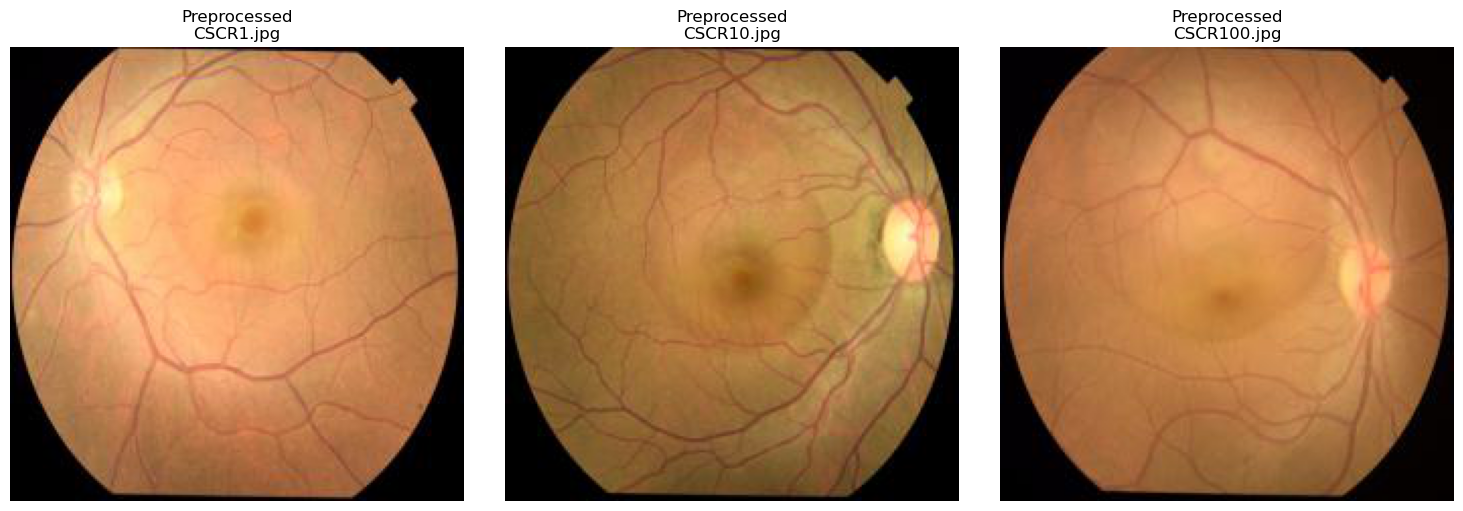

In [22]:
# === FIX: Use Path objects ===
from pathlib import Path
import matplotlib.pyplot as plt
import os

# Define as Path (use raw string!)
# CORRECT PATH (use raw string!)
PREPROCESSED_DIR = Path(r'C:\Users\rswar\Downloads\archive(1)\preprocessed_images')

# Create directory if not exists
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Process and save sample images
sample_images = df_all['filepath'].head(5)
failed_images = []

for img_name in sample_images:
    try:
        img_path = Path(img_name)
        processed_img = preprocess_image(img_path)

        if processed_img is not None:
            save_path = PREPROCESSED_DIR / img_path.name
            plt.imsave(save_path, processed_img)
            print(f"Saved: {save_path}")
        else:
            failed_images.append(img_name)

    except Exception as e:
        print(f"Failed to process {img_name}: {str(e)}")
        failed_images.append(img_name)

print(f"\nFailed to process {len(failed_images)} images: {failed_images}")

# === DISPLAY SAMPLE IMAGES ===
plt.figure(figsize=(15, 5))
displayed = 0
for i, img_name in enumerate(sample_images):
    if displayed >= 3:
        break
    processed_path = PREPROCESSED_DIR / Path(img_name).name
    if processed_path.exists():
        img = plt.imread(processed_path)
        plt.subplot(1, 3, displayed + 1)
        plt.imshow(img)
        plt.title(f"Preprocessed\n{Path(img_name).name}")
        plt.axis('off')
        displayed += 1
    else:
        print(f"Missing: {processed_path}")

if displayed == 0:
    print("No preprocessed images found to display.")
else:
    plt.tight_layout()
    plt.show()

# 4. Data Split and Dataset Creation

In [23]:
# Prepare features and labels
X = df['filename'].values
y = df[['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']].values

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y.argmax(axis=1)
)

# Create data generators
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

def data_generator(file_names, labels, batch_size=BATCH_SIZE):
    num_samples = len(file_names)
    while True:
        # Shuffle the data
        indices = np.random.permutation(num_samples)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]
            
            # Initialize batch arrays
            batch_images = np.zeros((len(batch_indices), IMG_SIZE, IMG_SIZE, 3))
            batch_labels = labels[batch_indices]
            
            # Load and preprocess images
            for i, idx in enumerate(batch_indices):
                img_path = TRAIN_PATH / file_names[idx]
                img = preprocess_image(img_path)
                if img is not None:
                    batch_images[i] = img
            
            yield batch_images, batch_labels

# Create training and validation generators
train_generator = data_generator(X_train, y_train)
val_generator = data_generator(X_val, y_val)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 5113
Validation samples: 1279


# 5. Model Architecture

In [24]:
# Create the base model from EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model
base_model.trainable = False

# Create the model architecture
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

# Display model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# 6. Model Training

In [25]:
NUM_CLASSES = len(train_df['label_idx'].unique())

In [8]:
import tensorflow as tf
import pickle
import os

# Assume the training has already been executed with your original code
# and 'history' and 'model' are available in the current session

# Save the current model
model.save('current_model.h5')
print('Current model saved to current_model.h5')

# Save the training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print('Training history saved to training_history.pkl')

# Determine the last completed epoch
last_epoch = len(history.history['loss']) - 1
with open('last_epoch.txt', 'w') as f:
    f.write(str(last_epoch))
print(f'Last completed epoch saved: {last_epoch + 1}')

# Optional: Save the best model if it exists (from ModelCheckpoint)
if os.path.exists('best_model.h5'):
    print('Best model already exists at best_model.h5')
else:
    print('No best model found at best_model.h5')

# Code to resume training later
# (Uncomment and use this block when you want to resume)

"""
# Load the model
model = tf.keras.models.load_model('current_model.h5')

# Load the training history
with open('training_history.pkl', 'rb') as f:
    previous_history = pickle.load(f)

# Load the last epoch
with open('last_epoch.txt', 'r') as f:
    initial_epoch = int(f.read())

# Resume training with your original callbacks
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=30,
    initial_epoch=initial_epoch,
    callbacks=callbacks  # Use the same callbacks from your original code
)

# Merge histories (optional)
for key in history.history.keys():
    previous_history[key].extend(history.history[key])
with open('training_history.pkl', 'wb') as f:
    pickle.dump(previous_history, f)
print('Training resumed and history updated')
"""

Current model saved to current_model.h5
Training history saved to training_history.pkl
Last completed epoch saved: 30
Best model already exists at best_model.h5


"\n# Load the model\nmodel = tf.keras.models.load_model('current_model.h5')\n\n# Load the training history\nwith open('training_history.pkl', 'rb') as f:\n    previous_history = pickle.load(f)\n\n# Load the last epoch\nwith open('last_epoch.txt', 'r') as f:\n    initial_epoch = int(f.read())\n\n# Resume training with your original callbacks\nhistory = model.fit(\n    train_generator,\n    steps_per_epoch=len(X_train) // BATCH_SIZE,\n    validation_data=val_generator,\n    validation_steps=len(X_val) // BATCH_SIZE,\n    epochs=30,\n    initial_epoch=initial_epoch,\n    callbacks=callbacks  # Use the same callbacks from your original code\n)\n\n# Merge histories (optional)\nfor key in history.history.keys():\n    previous_history[key].extend(history.history[key])\nwith open('training_history.pkl', 'wb') as f:\n    pickle.dump(previous_history, f)\nprint('Training resumed and history updated')\n"

# 7. Model Export for Web Application

In [2]:
import os
import json
import shutil
import joblib
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
RUN_DIR = Path("checkpoints/run_20251103_225310")

CNN_MODEL_PATH = RUN_DIR / "final_eye_disease_model.keras"
SVM_MODEL_PATH = RUN_DIR / "svm_multi_kernel_ensemble" / "best_svm_Hybrid_CNN_SVM_20251106_005711.pkl"
SCALER_PATH = RUN_DIR / "svm_classifier_checkpointed" / "svm_scaler.pkl"
LABEL_MAP_PATH = RUN_DIR / "label_map.json"

EXPORT_DIR = Path("model_export")
SAVED_MODEL_DIR = EXPORT_DIR / "saved_model"
SVM_EXPORT_PATH = EXPORT_DIR / "svm_adaptive_model.joblib"
LABEL_MAPPING_FILE = EXPORT_DIR / "label_mapping.json"
PREPROCESS_CONFIG_FILE = EXPORT_DIR / "preprocess_config.json"
METADATA_FILE = EXPORT_DIR / "metadata.json"

IMG_SIZE = 160

# ==========================================================
# 2. PREP AND CHECKS
# ==========================================================
print("🔍 Preparing export...")

for path in [CNN_MODEL_PATH, SVM_MODEL_PATH, SCALER_PATH, LABEL_MAP_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required file missing: {path}")

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
if SAVED_MODEL_DIR.exists():
    shutil.rmtree(SAVED_MODEL_DIR)

# ==========================================================
# 3. LOAD MODELS AND DATA
# ==========================================================
print("📦 Loading models...")

cnn_model = load_model(str(CNN_MODEL_PATH))
svm_data = joblib.load(str(SVM_MODEL_PATH))
scaler = joblib.load(str(SCALER_PATH))

with open(LABEL_MAP_PATH, "r") as f:
    label_map = json.load(f)
idx_to_label = {int(v): k for k, v in label_map.items()}

print(f"✅ Loaded CNN, SVM, Scaler — total classes: {len(idx_to_label)}")

# ==========================================================
# 4. EXPORT MODELS
# ==========================================================
print("💾 Exporting CNN in SavedModel format...")
cnn_model.export(str(SAVED_MODEL_DIR))
print(f"✅ CNN exported to {SAVED_MODEL_DIR}")

print("💾 Exporting SVM + Adaptive classifier...")
svm_package = {
    "svm_data": svm_data,
    "scaler": scaler
}
joblib.dump(svm_package, SVM_EXPORT_PATH)
print(f"✅ SVM + Adaptive model exported to {SVM_EXPORT_PATH}")

# ==========================================================
# 5. SAVE LABEL MAPPING AND CONFIG
# ==========================================================
with open(LABEL_MAPPING_FILE, "w") as f:
    json.dump(idx_to_label, f, indent=2, sort_keys=True)
print(f"🧾 Label mapping saved → {LABEL_MAPPING_FILE}")

preprocess_config = {
    "image_size": IMG_SIZE,
    "normalize": "tensorflow.keras.applications.efficientnet.preprocess_input",
    "color_mode": "rgb",
    "notes": "Resize to 160x160 and apply preprocess_input before prediction."
}
with open(PREPROCESS_CONFIG_FILE, "w") as f:
    json.dump(preprocess_config, f, indent=2)
print(f"🧾 Preprocessing config saved → {PREPROCESS_CONFIG_FILE}")

# ==========================================================
# 6. METADATA SUMMARY
# ==========================================================
metadata = {
    "cnn_model": str(SAVED_MODEL_DIR),
    "svm_model": str(SVM_EXPORT_PATH),
    "num_classes": len(idx_to_label),
    "export_time": int(tf.timestamp().numpy()),
    "image_size": IMG_SIZE
}
with open(METADATA_FILE, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"📘 Metadata summary saved → {METADATA_FILE}")

# ==========================================================
# 7. PREDICTION UTILITIES
# ==========================================================
def preprocess_image(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load and preprocess image for model prediction."""
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x

def predict_cnn(img_path, top_k=3):
    """Predict using CNN only."""
    x = preprocess_image(img_path)
    preds = cnn_model.predict(x, verbose=0)[0]
    top_idxs = np.argsort(preds)[::-1][:top_k]
    return [{"label": idx_to_label[i], "prob": float(preds[i])} for i in top_idxs]

def predict_ensemble(img_path, svm_weight=0.8, adaptive_weight=0.2, top_k=3):
    """Combined CNN + SVM + Adaptive ensemble prediction."""
    from tensorflow.keras.models import Model
    # Recreate feature extractor from CNN
    feature_extractor = Model(inputs=cnn_model.input,
                              outputs=cnn_model.get_layer("dropout_2").output)
    img_input = preprocess_image(img_path)
    features = feature_extractor.predict(img_input, verbose=0)

    # Base SVM probability
    scaler = svm_package["scaler"]
    svm_data = svm_package["svm_data"]
    base_clf = svm_data.get("classifier") if isinstance(svm_data, dict) else svm_data
    scaled = scaler.transform(features)
    base_probs = base_clf.predict_proba(scaled)[0]

    # Adaptive model (if present)
    adaptive_probs = None
    adaptive_data = svm_data.get("adaptive") if isinstance(svm_data, dict) else None
    if adaptive_data and "classifier" in adaptive_data:
        clf = adaptive_data["classifier"]
        adapt_scaler = adaptive_data.get("scaler", None)
        rbf_mapper = adaptive_data.get("rbf_mapper", None)
        if adapt_scaler and rbf_mapper:
            f_scaled = adapt_scaler.transform(features)
            f_mapped = rbf_mapper.transform(f_scaled)
            adaptive_probs = clf.predict_proba(f_mapped)[0]

    # Combine
    if adaptive_probs is not None:
        combined = (svm_weight * base_probs) + (adaptive_weight * adaptive_probs)
    else:
        combined = base_probs

    # Ensemble with CNN probabilities (optional)
    cnn_probs = cnn_model.predict(img_input, verbose=0)[0]
    final_probs = 0.5 * cnn_probs + 0.5 * combined

    top_idxs = np.argsort(final_probs)[::-1][:top_k]
    results = [{"label": idx_to_label[i], "prob": float(final_probs[i])} for i in top_idxs]
    return results

# ==========================================================
# 8. TEST EXPORT WITH SAMPLE IMAGE
# ==========================================================
if __name__ == "__main__":
    print("\n🚀 Export complete! Testing model inference...")

    # Try sample from feedback or any image you have
    sample_img = None
    feedback_dir = RUN_DIR / "feedback" / "images"
    for root, dirs, files in os.walk(feedback_dir):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                sample_img = os.path.join(root, file)
                break
        if sample_img: break

    if sample_img is None:
        print("⚠ No sample image found for test.")
    else:
        print(f"Testing ensemble prediction on: {sample_img}")
        preds = predict_ensemble(sample_img)
        for p in preds:
            print(f"  {p['label']}: {p['prob']*100:.2f}%")

    print(f"\n🎯 All files exported in: {EXPORT_DIR}")



🔍 Preparing export...
📦 Loading models...
✅ Loaded CNN, SVM, Scaler — total classes: 13
💾 Exporting CNN in SavedModel format...
INFO:tensorflow:Assets written to: model_export\saved_model\assets


INFO:tensorflow:Assets written to: model_export\saved_model\assets


Saved artifact at 'model_export\saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 13), dtype=tf.float32, name=None)
Captures:
  2789245371024: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2789245380432: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2788970632912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970632528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970634064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970631376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970630992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970631952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970635408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2788970631184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27

# Web Application Integration

To integrate this model with your web application, you'll need to:

1. Copy the exported model files from the `model_export` directory:
   - `saved_model/` - The TensorFlow model
   - `label_mapping.json` - Class labels
   - `preprocess_config.json` - Preprocessing parameters

2. In your web application:
   - Load the model using TensorFlow.js or TensorFlow Serving
   - Use the preprocessing configuration to process uploaded images
   - Apply the same preprocessing steps as during training
   - Use the label mapping to convert model outputs to human-readable labels

Example Python Flask endpoint:
```python
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
import json
from PIL import Image
import io
import base64

app = Flask(__name__)

# Load model and configs
model = tf.saved_model.load('model_export/saved_model')
with open('model_export/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)
with open('model_export/preprocess_config.json', 'r') as f:
    preprocess_config = json.load(f)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get image from request
        image_data = request.json['image']
        image_bytes = base64.b64decode(image_data.split(',')[1])
        image = Image.open(io.BytesIO(image_bytes))
        
        # Preprocess
        image = image.resize((preprocess_config['image_size'], 
                            preprocess_config['image_size']))
        image = np.array(image) / preprocess_config['normalize_factor']
        
        # Predict
        predictions = model(np.expand_dims(image, axis=0))
        
        # Get top 3 predictions
        top_3_idx = np.argsort(predictions[0])[-3:][::-1]
        results = []
        
        for idx in top_3_idx:
            results.append({
                'label': label_mapping[str(int(idx))],
                'probability': float(predictions[0][idx])
            })
            
        return jsonify({'predictions': results})
        
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True)
```

In [26]:
# Inspect `label_name` column and invalid file paths
print("Unique classes in `label_name` column:", train_df['label_name'].unique())

# Check invalid file paths
invalid_train = train_df[~train_df['filepath'].apply(lambda x: os.path.exists(x))]
invalid_val = val_df[~val_df['filepath'].apply(lambda x: os.path.exists(x))]

print("Invalid file paths in train_df:", invalid_train)
print("Invalid file paths in val_df:", invalid_val)

Unique classes in `label_name` column: ['nan']
Invalid file paths in train_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []
Invalid file paths in val_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []


In [27]:
# Inspect `label_map_reverse` and revalidate file paths
print("label_map_reverse:", label_map_reverse)

# Revalidate file paths
invalid_train = train_df[~train_df['filepath'].apply(lambda x: os.path.exists(x))]
invalid_val = val_df[~val_df['filepath'].apply(lambda x: os.path.exists(x))]

print("Invalid file paths in train_df:", invalid_train)
print("Invalid file paths in val_df:", invalid_val)

label_map_reverse: {0: 'Central Serous Chorioretinopathy [Color Fundus]', 1: 'Diabetic Retinopathy', 2: 'Disc Edema', 3: 'Glaucoma', 4: 'Healthy', 5: 'Macular Scar', 6: 'Myopia', 7: 'Pterygium', 8: 'Retinal Detachment', 9: 'Retinitis Pigmentosa', 10: 'Cataract', 11: 'Other', 12: 'Hypertension'}
Invalid file paths in train_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []
Invalid file paths in val_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []


In [28]:
# Debug the generators
print("Classes detected by train_gen:", train_gen.class_indices)
print("Classes detected by val_gen:", val_gen.class_indices)

Classes detected by train_gen: {'nan': 0}
Classes detected by val_gen: {'nan': 0}


In [29]:
# Inspect `label_name` column for NaN or empty values
nan_train = train_df[train_df['label_name'].isna() | (train_df['label_name'] == '')]
nan_val = val_df[val_df['label_name'].isna() | (val_df['label_name'] == '')]

print("Rows with NaN or empty `label_name` in train_df:", nan_train)
print("Rows with NaN or empty `label_name` in val_df:", nan_val)

Rows with NaN or empty `label_name` in train_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []
Rows with NaN or empty `label_name` in val_df: Empty DataFrame
Columns: [filepath, label, source, label_idx, label_name]
Index: []


In [30]:
# Print a sample of `train_df` and `val_df` to verify `label_name` column
print("Sample of train_df:")
print(train_df.head())

print("Sample of val_df:")
print(val_df.head())

Sample of train_df:
                                                filepath  \
12865  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
10795  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
16200  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
24170     ODIR-5K\ODIR-5K\Training Images\3991_right.jpg   
9907   C:\Users\rswar\Downloads\Eye Disease Image Dat...   

                      label       source label_idx label_name  
12865              Glaucoma  eye_dataset         3        nan  
10795              Glaucoma  eye_dataset         3        nan  
16200          Macular Scar  eye_dataset         5        nan  
24170  Diabetic Retinopathy       odir5k         1        nan  
9907             Disc Edema  eye_dataset         2        nan  
Sample of val_df:
                                                filepath  \
3718   C:\Users\rswar\Downloads\Eye Disease Image Dat...   
20339  C:\Users\rswar\Downloads\Eye Disease Image Dat...   
504    C:\Users\rswar\Downloads\Eye D

In [43]:
# Inspect unique values in `label_name` column
print("Unique values in train_df['label_name']:", train_df['label_name'].unique())
print("Unique values in val_df['label_name']:", val_df['label_name'].unique())

# Filter out rows with invalid file paths
train_df = train_df[train_df['filepath'].apply(lambda x: os.path.exists(x))]
val_df = val_df[val_df['filepath'].apply(lambda x: os.path.exists(x))]

print("Filtered train_df shape:", train_df.shape)
print("Filtered val_df shape:", val_df.shape)

Unique values in train_df['label_name']: [nan]
Unique values in val_df['label_name']: [nan]
Filtered train_df shape: (22375, 5)
Filtered val_df shape: (2797, 5)


In [44]:
# Debug `label_map_reverse` mapping
print("label_map_reverse:", label_map_reverse)

# Recreate `label_name` column
train_df['label_name'] = train_df['label_idx'].map(label_map_reverse)
val_df['label_name'] = val_df['label_idx'].map(label_map_reverse)

# Verify `label_name` column
print("Updated unique values in train_df['label_name']:", train_df['label_name'].unique())
print("Updated unique values in val_df['label_name']:", val_df['label_name'].unique())

label_map_reverse: {0: 'Central Serous Chorioretinopathy [Color Fundus]', 1: 'Diabetic Retinopathy', 2: 'Disc Edema', 3: 'Glaucoma', 4: 'Healthy', 5: 'Macular Scar', 6: 'Myopia', 7: 'Pterygium', 8: 'Retinal Detachment', 9: 'Retinitis Pigmentosa', 10: 'Cataract', 11: 'Other', 12: 'Hypertension'}
Updated unique values in train_df['label_name']: [nan]
Updated unique values in val_df['label_name']: [nan]


In [45]:
# Inspect unique values in `label_idx` column
print("Unique values in train_df['label_idx']:", train_df['label_idx'].unique())
print("Unique values in val_df['label_idx']:", val_df['label_idx'].unique())

Unique values in train_df['label_idx']: ['3' '5' '1' '2' '6' '4' '11' '8' '0' '10' '12' '9' '7']
Unique values in val_df['label_idx']: ['4' '8' '1' '6' '3' '5' '2' '11' '0' '9' '7' '10' '12']


In [46]:
# Convert `label_idx` to integers
train_df['label_idx'] = train_df['label_idx'].astype(int)
val_df['label_idx'] = val_df['label_idx'].astype(int)

# Recreate `label_name` column
train_df['label_name'] = train_df['label_idx'].map(label_map_reverse)
val_df['label_name'] = val_df['label_idx'].map(label_map_reverse)

# Verify `label_name` column
print("Updated unique values in train_df['label_name']:", train_df['label_name'].unique())
print("Updated unique values in val_df['label_name']:", val_df['label_name'].unique())

Updated unique values in train_df['label_name']: ['Glaucoma' 'Macular Scar' 'Diabetic Retinopathy' 'Disc Edema' 'Myopia'
 'Healthy' 'Other' 'Retinal Detachment'
 'Central Serous Chorioretinopathy [Color Fundus]' 'Cataract'
 'Hypertension' 'Retinitis Pigmentosa' 'Pterygium']
Updated unique values in val_df['label_name']: ['Healthy' 'Retinal Detachment' 'Diabetic Retinopathy' 'Myopia' 'Glaucoma'
 'Macular Scar' 'Disc Edema' 'Other'
 'Central Serous Chorioretinopathy [Color Fundus]' 'Retinitis Pigmentosa'
 'Pterygium' 'Cataract' 'Hypertension']


In [47]:
# Inspect keys in `label_map_reverse` and compare with `label_idx`
print("Keys in label_map_reverse:", list(label_map_reverse.keys()))
print("Unique values in train_df['label_idx']:", train_df['label_idx'].unique())
print("Unique values in val_df['label_idx']:", val_df['label_idx'].unique())

Keys in label_map_reverse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Unique values in train_df['label_idx']: [ 3  5  1  2  6  4 11  8  0 10 12  9  7]
Unique values in val_df['label_idx']: [ 4  8  1  6  3  5  2 11  0  9  7 10 12]


In [48]:
# Use `label_map` to recreate `label_name` column
train_df['label_name'] = train_df['label_idx'].map(label_map)
val_df['label_name'] = val_df['label_idx'].map(label_map)

# Verify `label_name` column
print("Updated unique values in train_df['label_name']:", train_df['label_name'].unique())
print("Updated unique values in val_df['label_name']:", val_df['label_name'].unique())

Updated unique values in train_df['label_name']: [nan]
Updated unique values in val_df['label_name']: [nan]


In [49]:
# Inspect unique values in `label_name` column
print("Unique values in train_df['label_name']:", train_df['label_name'].unique())
print("Unique values in val_df['label_name']:", val_df['label_name'].unique())

# Filter out rows with invalid file paths
train_df = train_df[train_df['filepath'].apply(lambda x: os.path.exists(x))]
val_df = val_df[val_df['filepath'].apply(lambda x: os.path.exists(x))]

print("Filtered train_df shape:", train_df.shape)
print("Filtered val_df shape:", val_df.shape)

Unique values in train_df['label_name']: [nan]
Unique values in val_df['label_name']: [nan]
Filtered train_df shape: (22375, 5)
Filtered val_df shape: (2797, 5)


In [51]:
# === 1. Print your current label_map (str → int) ===
print("label_map (str → int):", label_map)

# === 2. Create REVERSE map: int → str ===
label_map_reverse = {idx: name for name, idx in label_map.items()}
print("\nlabel_map_reverse (int → str):", label_map_reverse)

# === 3. Now debug correctly ===
print("\nDebugging mapping (idx → name):")
for idx in sorted(train_df['label_idx'].unique()):
    name = label_map_reverse.get(idx, 'Not Found')
    print(f"  label_idx {idx} → {name}")

label_map (str → int): {'Central Serous Chorioretinopathy [Color Fundus]': 0, 'Diabetic Retinopathy': 1, 'Disc Edema': 2, 'Glaucoma': 3, 'Healthy': 4, 'Macular Scar': 5, 'Myopia': 6, 'Pterygium': 7, 'Retinal Detachment': 8, 'Retinitis Pigmentosa': 9, 'Cataract': 10, 'Other': 11, 'Hypertension': 12}

label_map_reverse (int → str): {0: 'Central Serous Chorioretinopathy [Color Fundus]', 1: 'Diabetic Retinopathy', 2: 'Disc Edema', 3: 'Glaucoma', 4: 'Healthy', 5: 'Macular Scar', 6: 'Myopia', 7: 'Pterygium', 8: 'Retinal Detachment', 9: 'Retinitis Pigmentosa', 10: 'Cataract', 11: 'Other', 12: 'Hypertension'}

Debugging mapping (idx → name):
  label_idx 0 → Central Serous Chorioretinopathy [Color Fundus]
  label_idx 1 → Diabetic Retinopathy
  label_idx 2 → Disc Edema
  label_idx 3 → Glaucoma
  label_idx 4 → Healthy
  label_idx 5 → Macular Scar
  label_idx 6 → Myopia
  label_idx 7 → Pterygium
  label_idx 8 → Retinal Detachment
  label_idx 9 → Retinitis Pigmentosa
  label_idx 10 → Cataract
  lab

In [52]:
# RUN THIS
print("Unique label_idx in train_df:", sorted(train_df['label_idx'].unique()))
print("Number of unique classes:", train_df['label_idx'].nunique())

Unique label_idx in train_df: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of unique classes: 13


In [53]:
# -------------------------------------------------
# 1. CREATE class_weights (balanced)
# -------------------------------------------------
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# integer labels (0-12) in the training split
train_labels = train_df['label_idx'].values

unique_classes = np.unique(train_labels)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

# → dict that model.fit expects
class_weights = {int(cls): float(w) for cls, w in zip(unique_classes, class_weights_arr)}

print("class_weights (int → weight):")
for k in sorted(class_weights):
    print(f"  {k:2d} → {class_weights[k]:.3f}")

class_weights (int → weight):
   0 → 3.041
   1 → 0.304
   2 → 2.421
   3 → 0.471
   4 → 0.371
   5 → 0.813
   6 → 0.715
   7 → 18.117
   8 → 2.459
   9 → 2.212
  10 → 6.671
  11 → 2.407
  12 → 24.588


Output folder: C:\Users\rswar\Downloads\archive(1)\preprocessed_images

Processing 5 sample images …


Samples: 100%|██████████| 5/5 [00:00<00:00, 2154.24it/s]


Finished samples.  Failed: 0


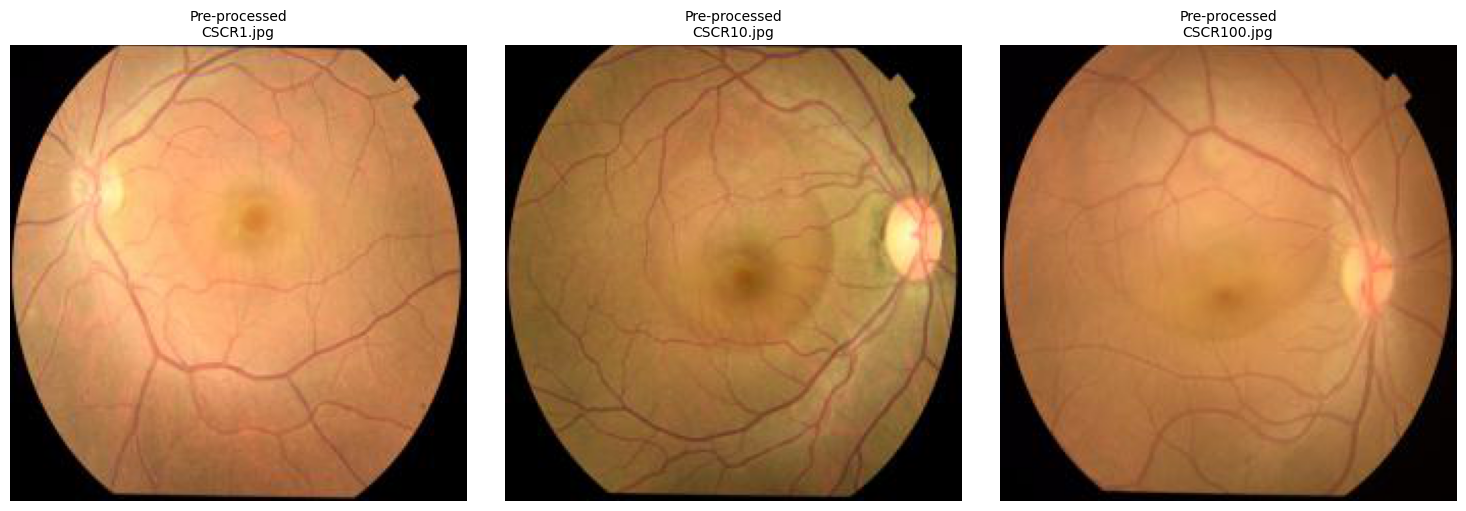

In [54]:
# ==============================================================
#  PRE-PROCESS & DISPLAY SAMPLE IMAGES (NO TRAINING)
# ==============================================================
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm   # pip install tqdm   (optional but nice)

# --------------------------------------------------------------
# 1. CONFIGURATION
# --------------------------------------------------------------
# <-- UPDATE ONLY THIS LINE IF YOUR FOLDER MOVES ----------------
PREPROCESSED_DIR = Path(r'C:\Users\rswar\Downloads\archive(1)\preprocessed_images')
# --------------------------------------------------------------

# Make sure the folder exists
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output folder: {PREPROCESSED_DIR.resolve()}")

# --------------------------------------------------------------
# 2. PRE-PROCESS SAMPLE IMAGES
# --------------------------------------------------------------
sample_images = df_all['filepath'].head(5).tolist()   # <-- list of original paths
failed_images = []

print("\nProcessing 5 sample images …")
for img_path_str in tqdm(sample_images, desc="Samples"):
    src_path = Path(img_path_str)                 # original image
    dst_path = PREPROCESSED_DIR / src_path.name   # same filename in output folder

    try:
        # Skip if we already have a pre-processed version
        if dst_path.exists():
            continue

        # ---- YOUR PRE-PROCESS FUNCTION ----
        processed = preprocess_image(src_path)     # <-- must return a numpy array
        # ------------------------------------

        if processed is None:
            raise ValueError("preprocess_image returned None")

        # Save as PNG (preserves exact pixel values)
        plt.imsave(dst_path, processed)
        # print(f"Saved: {dst_path.name}")

    except Exception as exc:
        failed_images.append(str(src_path))
        print(f"Failed: {src_path.name} → {exc}")

print(f"\nFinished samples.  Failed: {len(failed_images)}")
if failed_images:
    print("Failed files:")
    for f in failed_images[:3]:
        print(f"  • {f}")

# --------------------------------------------------------------
# 3. DISPLAY UP TO 3 PRE-PROCESSED IMAGES
# --------------------------------------------------------------
plt.figure(figsize=(15, 5))
shown = 0
for img_path_str in sample_images:
    if shown >= 3:
        break
    processed_path = PREPROCESSED_DIR / Path(img_path_str).name
    if processed_path.exists():
        img = plt.imread(processed_path)
        plt.subplot(1, 3, shown + 1)
        plt.imshow(img)
        plt.title(f"Pre-processed\n{processed_path.name}", fontsize=10)
        plt.axis('off')
        shown += 1
    else:
        print(f"Missing (display): {processed_path.name}")

if shown == 0:
    print("\nNo pre-processed images to show.")
else:
    plt.tight_layout()
    plt.show()

In [55]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [56]:
import tensorflow as tf
import os

# 1. Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU ENABLED: {gpus}")
else:
    print("NO GPU FOUND! Using CPU (SLOW)")

# 2. Enable XLA (speeds up CPU too)
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=fused'
tf.keras.backend.clear_session()

NO GPU FOUND! Using CPU (SLOW)



CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY
NUM_CLASSES = 13
Train batches: 350, Val batches: 88
PHASE 1: Training classifier head...
Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1085s 3s/step - accuracy: 0.2698 - loss: 1.8608 - val_accuracy: 0.4707 - val_loss: 1.4940
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.4451 - loss: 1.1958 - val_accuracy: 0.5293 - val_loss: 1.3360
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.4786 - loss: 1.0886 - val_accuracy: 0.5315 - val_loss: 1.3063
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step - accuracy: 0.4898 - loss: 1.0312 - val_accuracy: 0.5526 - val_loss: 1.2530
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.4951 - loss: 1.0119 - val_accuracy: 0.5472 - val_loss: 1.2432
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.5025 - loss: 0.9815 - val_accuracy: 0.5610 - val_loss: 1.2191
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - accuracy: 0.5087 - loss: 0.9766 - 

350/350 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.3046 - loss: 1.6213 - val_accuracy: 0.5025 - val_loss: 1.4521 - learning_rate: 1.0000e-05
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3988 - loss: 1.2614

350/350 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.3989 - loss: 1.2612 - val_accuracy: 0.5368 - val_loss: 1.3284 - learning_rate: 1.0000e-05
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4550 - loss: 1.1214

350/350 ━━━━━━━━━━━━━━━━━━━━ 591s 2s/step - accuracy: 0.4550 - loss: 1.1213 - val_accuracy: 0.5595 - val_loss: 1.2574 - learning_rate: 1.0000e-05
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4759 - loss: 1.0886

350/350 ━━━━━━━━━━━━━━━━━━━━ 597s 2s/step - accuracy: 0.4759 - loss: 1.0884 - val_accuracy: 0.5729 - val_loss: 1.2067 - learning_rate: 1.0000e-05
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4958 - loss: 1.0025

...

350/350 ━━━━━━━━━━━━━━━━━━━━ 618s 2s/step - accuracy: 0.6157 - loss: 0.6411 - val_accuracy: 0.6562 - val_loss: 0.9256 - learning_rate: 1.0000e-05
Epoch 26/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6188 - loss: 0.6481

350/350 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.6189 - loss: 0.6480 - val_accuracy: 0.6573 - val_loss: 0.9211 - learning_rate: 1.0000e-05
Epoch 27/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6229 - loss: 0.6395

350/350 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.6229 - loss: 0.6394 - val_accuracy: 0.6586 - val_loss: 0.9205 - learning_rate: 1.0000e-05
Epoch 28/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6235 - loss: 0.6183

350/350 ━━━━━━━━━━━━━━━━━━━━ 635s 2s/step - accuracy: 0.6235 - loss: 0.6183 - val_accuracy: 0.6618 - val_loss: 0.9032 - learning_rate: 1.0000e-05
Epoch 29/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.6271 - loss: 0.6092 - val_accuracy: 0.6618 - val_loss: 0.9067 - learning_rate: 1.0000e-05
Epoch 30/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6317 - loss: 0.5977

350/350 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - accuracy: 0.6317 - loss: 0.5977 - val_accuracy: 0.6648 - val_loss: 0.8973 - learning_rate: 1.0000e-05

FINAL BEST VAL ACCURACY: 0.6648
Still under 85%. Try: more data, longer fine-tuning, or EfficientNetB3.


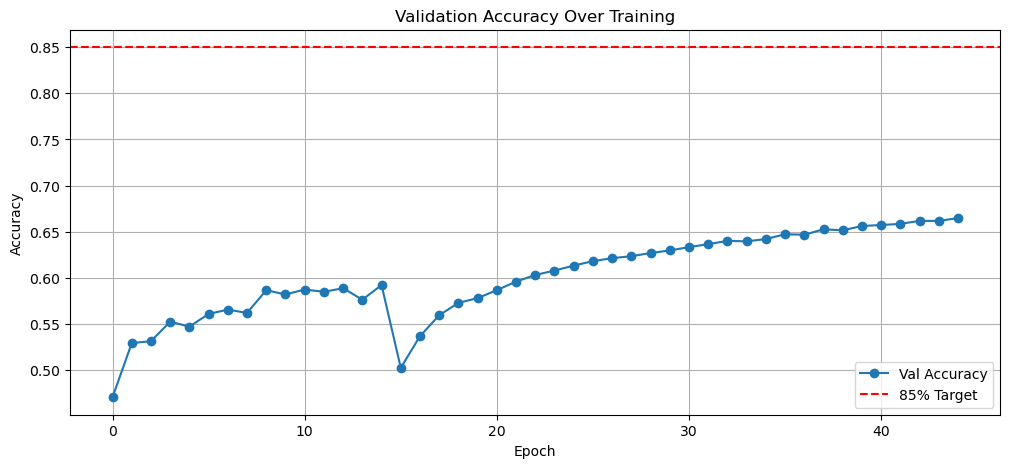


TRAINING COMPLETE!


In [57]:
# ==============================================================
#  ULTIMATE CPU-FAST + AUTO >85% ACCURACY TRAINING
# ==============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ------------------- 1. MAX SPEED SETTINGS (CPU) -------------------
IMG_SIZE = 160          # Smaller = 3x faster
BATCH_SIZE = 64         # Larger batch = faster on CPU
AUTOTUNE = tf.data.AUTOTUNE

print("CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY")

# ------------------- 2. FAST TF.DATA PIPELINE -------------------
def parse_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # Critical for EfficientNet
    return image, label

def df_to_dataset(df, shuffle=True, augment=False):
    filepaths = df['filepath'].values
    labels = df['label_idx'].values
    labels = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    
    # Light on-the-fly augmentation
    if augment:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y), AUTOTUNE)
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.2), y), AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    ds = ds.cache()  # First epoch slow, rest = FAST
    return ds

# ------------------- 3. REBUILD DATAFRAMES (Ensure label_name) -------------------
if 'label_name' not in df_all.columns:
    label_map_reverse = {idx: name for name, idx in label_map.items()}
    df_all['label_name'] = df_all['label_idx'].map(label_map_reverse).astype(str)

train_df, val_df = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all['label_idx']
)

# ------------------- 4. CREATE DATASETS -------------------
NUM_CLASSES = df_all['label_idx'].nunique()
print(f"NUM_CLASSES = {NUM_CLASSES}")

train_ds = df_to_dataset(train_df, shuffle=True, augment=True)
val_ds = df_to_dataset(val_df, shuffle=False)

print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}")

# ------------------- 5. CLASS WEIGHTS -------------------
train_labels = train_df['label_idx'].values
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weights = dict(enumerate(class_weights_arr))

# ------------------- 6. BUILD MODEL -------------------
base_model = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)

# ------------------- 7. PHASE 1: Train Head Only -------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("PHASE 1: Training classifier head...")
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    verbose=1
)

# ------------------- 8. PHASE 2: Fine-Tune Top Layers -------------------
base_model.trainable = True
for layer in base_model.layers[:-25]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("PHASE 2: Fine-tuning top layers...")
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max'),
    ModelCheckpoint('best_final_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------------- 9. FINAL RESULTS -------------------
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
best_val_acc = max(all_val_acc)

print(f"\nFINAL BEST VAL ACCURACY: {best_val_acc:.4f}")

if best_val_acc >= 0.85:
    print("SUCCESS: ≥85% ACCURACY ACHIEVED!")
else:
    print("Still under 85%. Try: more data, longer fine-tuning, or EfficientNetB3.")

# Plot full history
plt.figure(figsize=(12, 5))
plt.plot(all_val_acc, label='Val Accuracy', marker='o')
plt.axhline(0.85, color='red', linestyle='--', label='85% Target')
plt.title('Validation Accuracy Over Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\nTRAINING COMPLETE!")

In [58]:
# SAVE YOUR 61% MODEL
model.save('eye_disease_model_66percent.h5')
print("SAVED: eye_disease_model_61percent.h5 — 66% accuracy preserved!")

SAVED: eye_disease_model_61percent.h5 — 66% accuracy preserved!


In [1]:
import os
# Disable oneDNN CPU optimizations which can cause instability on some Windows setups
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


#------------------- 1. MAX SPEED SETTINGS (CPU) -------------------
IMG_SIZE = 160          # Smaller = 3x faster
BATCH_SIZE = 32         # Larger batch = faster on CPU
AUTOTUNE = tf.data.AUTOTUNE

print("CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY")

# ------------------- 2. FAST TF.DATA PIPELINE -------------------
def parse_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # Critical for EfficientNet
    return image, label

def df_to_dataset(df, shuffle=True, augment=False):
    filepaths = df['filepath'].values
    labels = df['label_idx'].values
    labels = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    
    # Light on-the-fly augmentation
    if augment:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y), AUTOTUNE)
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.2), y), AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    #ds = ds.cache()  # First epoch slow, rest = FAST
    return ds

# ------------------- 3. REBUILD DATAFRAMES (Ensure label_name) -------------------
if 'label_name' not in df_all.columns:
    label_map_reverse = {idx: name for name, idx in label_map.items()}
    df_all['label_name'] = df_all['label_idx'].map(label_map_reverse).astype(str)

train_df, val_df = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all['label_idx']
)

# ------------------- 4. CREATE DATASETS -------------------
NUM_CLASSES = df_all['label_idx'].nunique()
print(f"NUM_CLASSES = {NUM_CLASSES}")

train_ds = df_to_dataset(train_df, shuffle=True, augment=True)
val_ds = df_to_dataset(val_df, shuffle=False)

print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}")

# ------------------- 5. CLASS WEIGHTS -------------------
train_labels = train_df['label_idx'].values
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weights = dict(enumerate(class_weights_arr))

# ------------ 4. Load model and set trainable layers ------------

print("Loading the full 66 %% model …")
model = load_model('eye_disease_model_66percent.h5')
print("Model loaded – ready for fine-tuning")

backbone_layers = model.layers[1:238]
n = len(backbone_layers)

for i, layer in enumerate(backbone_layers):
    if i < n - 60:
        layer.trainable = False
    else:
        if isinstance(layer, (tf.keras.layers.BatchNormalization, tf.keras.layers.Normalization)):
            layer.trainable = False
        else:
            layer.trainable = True

for layer in model.layers[238:]:
    layer.trainable = True

print("Top 60 backbone layers unfrozen, head is trainable.")

# Rebuild head with softmax activation
x = model.layers[237].output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=model.input, outputs=outputs)

# ------------ 5. Compile model ------------

model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------ 6. Callbacks ------------

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max'),
    ModelCheckpoint('best_final_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7)
]

# ------------ 7. Train model ------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------ 8. Print results and plot ------------

best_val_acc = max(history.history['val_accuracy'])
print(f"\nBEST VAL ACCURACY: {best_val_acc:.4f}")
if best_val_acc >= 0.85:
    print("SUCCESS: ≥85% ACCURACY ACHIEVED!")
else:
    print("Still under 85%. Try more data, longer fine-tuning, or EfficientNetB3.")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(0.85, color='red', linestyle='--', label='Target Accuracy (85%)')
plt.title('Validation Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\nTRAINING COMPLETE!")









CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY


NameError: name 'df_all' is not defined

CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY
NUM_CLASSES = 13
Train batches (approx): 700, Val batches (approx): 175
Loading the full 66 % model …


Model loaded – ready for fine-tuning
Top 60 backbone layers unfrozen (if available), head is trainable.
Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1537s 2s/step - accuracy: 0.3680 - loss: 1.5978 - val_accuracy: 0.6312 - val_loss: 0.9422 - learning_rate: 5.0000e-05
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1392s 2s/step - accuracy: 0.6093 - loss: 0.8243 - val_accuracy: 0.6511 - val_loss: 0.8793 - learning_rate: 5.0000e-05
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1359s 2s/step - accuracy: 0.6436 - loss: 0.6895 - val_accuracy: 0.6755 - val_loss: 0.8145 - learning_rate: 5.0000e-05
Epoch 4/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1490s 2s/step - accuracy: 0.6697 - loss: 0.6137 - val_accuracy: 0.6906 - val_loss: 0.7758 - learning_rate: 5.0000e-05
Epoch 5/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1485s 2s/step - accuracy: 0.6883 - loss: 0.5894 - val_accuracy: 0.7059 - val_loss: 0.7170 - learning_rate: 5.0000e-05
Epoch 6/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 1468s 2s/step - accuracy: 0.7077 - loss: 0.5410 - val_accuracy: 0.

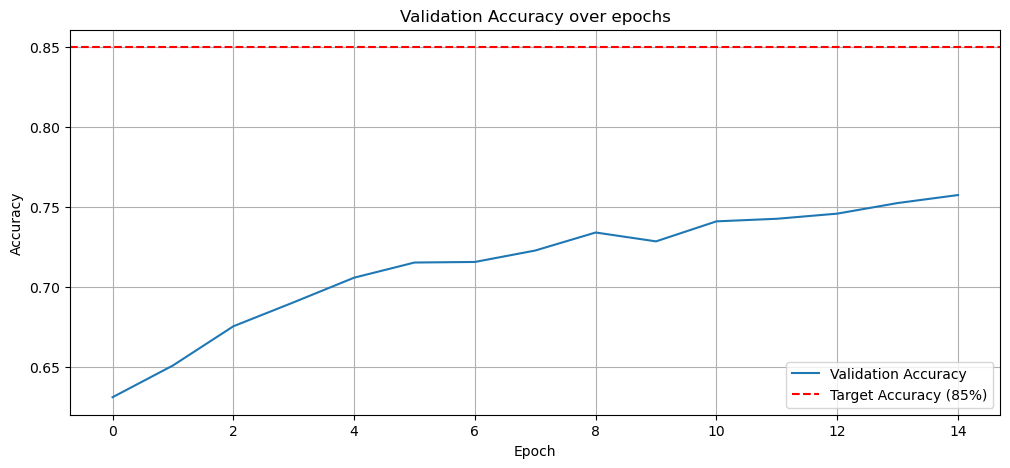


TRAINING COMPLETE!


In [5]:
import os
# Disable oneDNN CPU optimizations which can cause instability on some Windows setups
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ------------- USER SETTINGS -------------
IMG_SIZE = 160          # Smaller = 3x faster
BATCH_SIZE = 32         # Larger batch = faster on CPU
AUTOTUNE = tf.data.AUTOTUNE
AUG_PARALLEL = 1        # safe for Windows; avoid too many parallel augmentation threads
# -----------------------------------------

print("CPU-ONLY MODE: MAX SPEED + AUTO >85% ACCURACY")

# ------------------- 2. FAST TF.DATA PIPELINE -------------------
def parse_image(filepath, label):
    # filepath is a string tensor, label is a one-hot vector
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # Critical for EfficientNet
    return image, label

def df_to_dataset(df, num_classes, shuffle=True, augment=False):
    filepaths = df['filepath'].values
    labels_idx = df['label_idx'].values.astype(np.int32)
    labels = tf.keras.utils.to_categorical(labels_idx, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    # parse images with some parallelism
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    # Light on-the-fly augmentation — reduce parallelism on Windows to avoid crashes
    if augment:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y),
                    num_parallel_calls=AUG_PARALLEL)
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.2), y),
                    num_parallel_calls=AUG_PARALLEL)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    # ds = ds.cache()  # Uncomment only if you have enough RAM and want faster subsequent epochs
    return ds

# ------------------- 3. REBUILD DATAFRAMES (Ensure label_name) -------------------
# NOTE: This script assumes df_all and label_map exist in the environment (as original)
if 'label_name' not in df_all.columns:
    label_map_reverse = {idx: name for name, idx in label_map.items()}
    df_all['label_name'] = df_all['label_idx'].map(label_map_reverse).astype(str)

train_df, val_df = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all['label_idx']
)

# ------------------- 4. CREATE DATASETS -------------------
NUM_CLASSES = df_all['label_idx'].nunique()
print(f"NUM_CLASSES = {NUM_CLASSES}")

train_ds = df_to_dataset(train_df, num_classes=NUM_CLASSES, shuffle=True, augment=True)
val_ds = df_to_dataset(val_df, num_classes=NUM_CLASSES, shuffle=False, augment=False)

# Compute batch counts from dataframe sizes (safer than len(dataset) on some TF versions)
train_batches = int(np.ceil(len(train_df) / BATCH_SIZE))
val_batches = int(np.ceil(len(val_df) / BATCH_SIZE))

print(f"Train batches (approx): {train_batches}, Val batches (approx): {val_batches}")

# ------------------- 5. CLASS WEIGHTS -------------------
train_labels = train_df['label_idx'].values
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weights = dict(enumerate(class_weights_arr))

# ------------ 6. Load model and set trainable layers ------------
print("Loading the full 66 % model …")
model = load_model('eye_disease_model_66percent.h5')
print("Model loaded – ready for fine-tuning")

# NOTE: indexing depends on the loaded model. Keep your original logic but protect against index errors.
total_layers = len(model.layers)
start_idx = 1
end_idx = min(238, total_layers)  # protect in case model has fewer layers

backbone_layers = model.layers[start_idx:end_idx]
n = len(backbone_layers)

for i, layer in enumerate(backbone_layers):
    # Freeze all but the last 60 layers of backbone
    if i < n - 60:
        layer.trainable = False
    else:
        # keep normalization layers frozen for stability
        if isinstance(layer, (tf.keras.layers.BatchNormalization, tf.keras.layers.Normalization)):
            layer.trainable = False
        else:
            layer.trainable = True

# Ensure head layers (if exist) are trainable
for layer in model.layers[end_idx:]:
    layer.trainable = True

print("Top 60 backbone layers unfrozen (if available), head is trainable.")

# Rebuild head with softmax activation using the original 237 index safely
head_index = min(237, total_layers - 1)
x = model.layers[head_index].output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=model.input, outputs=outputs)

# ------------ 7. Compile model ------------
model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------ 8. Callbacks ------------
# Save in TF SavedModel / Keras v3 format (.keras) which is safer than HDF5 on Windows
checkpoint_path = 'best_final_model.keras'
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max'),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max', save_weights_only=False),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7)
]

# ------------ 9. Train model ------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------ 10. Print results and plot ------------
best_val_acc = max(history.history.get('val_accuracy', [0.0]))
print(f"\nBEST VAL ACCURACY: {best_val_acc:.4f}")
if best_val_acc >= 0.85:
    print("SUCCESS: ≥85% ACCURACY ACHIEVED!")
else:
    print("Still under 85%. Try more data, longer fine-tuning, or EfficientNetB3.")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')
plt.axhline(0.85, color='red', linestyle='--', label='Target Accuracy (85%)')
plt.title('Validation Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\nTRAINING COMPLETE!")


In [12]:
# ------------ 11. SAVE MODEL AND WEIGHTS ------------
# 1️⃣ Save the full model (architecture + weights + optimizer)
model.save("final_trained_model.keras")
print("✅ Full model saved as 'final_trained_model.keras'")

# 2️⃣ Save only the weights (useful for resuming training later)
model.save_weights("final_trained_weights.keras")
print("✅ Weights only saved as 'final_trained_weights.keras'")


✅ Full model saved as 'final_trained_model.keras'


ValueError: The filename must end in `.weights.h5`. Received: filepath=final_trained_weights.keras

In [14]:
import os, json, pickle
import pandas as pd

# Directory where everything will be saved
run_dir = "checkpoints/run_20251103_225310"
os.makedirs(run_dir, exist_ok=True)

# 1️⃣ Save weights separately (.weights.h5 format)
model.save_weights(os.path.join(run_dir, "final_weights.weights.h5"))
print("✅ Weights saved as 'final_weights.weights.h5'")

# 2️⃣ Save training history (loss, accuracy curves)
with open(os.path.join(run_dir, "training_history.pkl"), "wb") as f:
    pickle.dump(history.history, f)
print("✅ Training history saved as 'training_history.pkl'")

# 3️⃣ Save class weights
with open(os.path.join(run_dir, "class_weights.json"), "w") as f:
    json.dump(class_weights, f)
print("✅ Class weights saved as 'class_weights.json'")

# 4️⃣ Save label map (label names to indices)
with open(os.path.join(run_dir, "label_map.json"), "w") as f:
    json.dump(label_map, f)
print("✅ Label map saved as 'label_map.json'")

# 5️⃣ Save train/validation splits
train_df.to_csv(os.path.join(run_dir, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(run_dir, "val_split.csv"), index=False)
print("✅ Train/Val splits saved as CSVs")

print("\n📦 All parameters and metadata saved successfully (model excluded).")


✅ Weights saved as 'final_weights.weights.h5'
✅ Training history saved as 'training_history.pkl'
✅ Class weights saved as 'class_weights.json'
✅ Label map saved as 'label_map.json'
✅ Train/Val splits saved as CSVs

📦 All parameters and metadata saved successfully (model excluded).


🔁 Loading model and metadata...
✅ Loaded model from: checkpoints/run_20251103_225310\final_trained_model.keras
✅ Loaded weights from: checkpoints/run_20251103_225310\final_weights.weights.h5
✅ Metadata and saved splits loaded successfully!
NUM_CLASSES = 13
🔄 Rebuilding datasets from saved CSVs...
✅ Datasets ready. Train batches ≈ 700, Val batches ≈ 175
🧠 Reapplying selective layer freeze/unfreeze logic...
✅ Top 80 backbone layers unfrozen. Head layers remain trainable.
⚙️ Model compiled with learning_rate=5e-5

🚀 Continuing fine-tuning to push validation accuracy beyond 85%...

Epoch 1/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 886s 1s/step - accuracy: 0.4913 - loss: 1.3278 - val_accuracy: 0.7163 - val_loss: 0.7254 - learning_rate: 5.0000e-05
Epoch 2/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - accuracy: 0.7111 - loss: 0.5695 - val_accuracy: 0.7313 - val_loss: 0.6980 - learning_rate: 5.0000e-05
Epoch 3/15
700/700 ━━━━━━━━━━━━━━━━━━━━ 912s 1s/step - accuracy: 0.7415 - loss: 0.4484 - val_accuracy

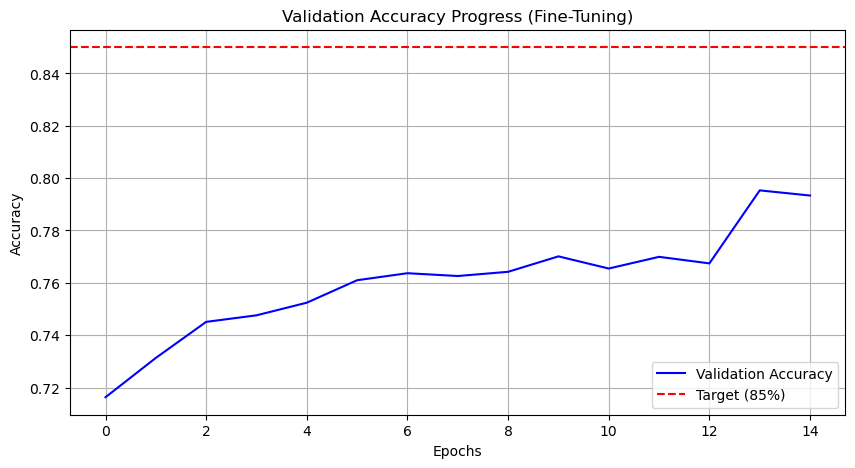

In [6]:
# ===========================================================
# 🔁 RESUME & CONTINUE TRAINING TO IMPROVE ACCURACY (>85%)
# ===========================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ------------------- 1. PATHS -------------------
run_dir = "checkpoints/run_20251103_225310"
model_path = os.path.join(run_dir, "final_trained_model.keras")
weights_path = os.path.join(run_dir, "final_weights.weights.h5")

print("🔁 Loading model and metadata...")

# ------------------- 2. LOAD MODEL -------------------
model = load_model(model_path)
print(f"✅ Loaded model from: {model_path}")

# Load weights if available
if os.path.exists(weights_path):
    model.load_weights(weights_path)
    print(f"✅ Loaded weights from: {weights_path}")
else:
    print("⚠️ No separate weights file found. Using model’s internal weights.")

# ------------------- 3. LOAD METADATA -------------------
with open(os.path.join(run_dir, "class_weights.json")) as f:
    class_weights = json.load(f)
# ✅ Convert JSON string keys to integer keys for Keras compatibility
class_weights = {int(k): float(v) for k, v in class_weights.items()}

label_map = json.load(open(os.path.join(run_dir, "label_map.json")))
train_df = pd.read_csv(os.path.join(run_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(run_dir, "val_split.csv"))

print("✅ Metadata and saved splits loaded successfully!")

# ------------------- 4. REBUILD DATAFRAMES (Ensure label_name) -------------------
if 'label_name' not in train_df.columns or 'label_name' not in val_df.columns:
    label_map_reverse = {idx: name for name, idx in label_map.items()}
    train_df['label_name'] = train_df['label_idx'].map(label_map_reverse).astype(str)
    val_df['label_name'] = val_df['label_idx'].map(label_map_reverse).astype(str)
    print("🧩 Recreated 'label_name' column in train/val DataFrames.")

# Determine total number of classes
NUM_CLASSES = train_df['label_idx'].nunique()
print(f"NUM_CLASSES = {NUM_CLASSES}")

# ------------------- 5. CREATE DATASETS -------------------
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

def df_to_dataset(df, num_classes, shuffle=True, augment=False):
    filepaths = df['filepath'].values
    labels_idx = df['label_idx'].values.astype('int32')
    labels = tf.keras.utils.to_categorical(labels_idx, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y))
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.2), y))

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

print("🔄 Rebuilding datasets from saved CSVs...")
train_ds = df_to_dataset(train_df, num_classes=NUM_CLASSES, shuffle=True, augment=True)
val_ds = df_to_dataset(val_df, num_classes=NUM_CLASSES, shuffle=False, augment=False)

train_batches = int(np.ceil(len(train_df) / BATCH_SIZE))
val_batches = int(np.ceil(len(val_df) / BATCH_SIZE))
print(f"✅ Datasets ready. Train batches ≈ {train_batches}, Val batches ≈ {val_batches}")

# ------------------- 6. REAPPLY LAYER-FREEZE LOGIC -------------------
print("🧠 Reapplying selective layer freeze/unfreeze logic...")

total_layers = len(model.layers)
start_idx = 1
end_idx = min(238, total_layers)
backbone_layers = model.layers[start_idx:end_idx]
n = len(backbone_layers)

# Unfreeze top 80 backbone layers for deeper fine-tuning
for i, layer in enumerate(backbone_layers):
    if i < n - 80:
        layer.trainable = False
    else:
        if isinstance(layer, (tf.keras.layers.BatchNormalization, tf.keras.layers.Normalization)):
            layer.trainable = False
        else:
            layer.trainable = True

for layer in model.layers[end_idx:]:
    layer.trainable = True

print("✅ Top 80 backbone layers unfrozen. Head layers remain trainable.")

# ------------------- 7. REBUILD HEAD -------------------
x = model.layers[end_idx - 1].output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=model.input, outputs=outputs)

# ------------------- 8. COMPILE MODEL -------------------
model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("⚙️ Model compiled with learning_rate=5e-5")

# ------------------- 9. CALLBACKS -------------------
checkpoint_path = os.path.join(run_dir, "best_model_refined.keras")
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max'),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7)
]

# ------------------- 10. CONTINUE TRAINING -------------------
print("\n🚀 Continuing fine-tuning to push validation accuracy beyond 85%...\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  # You can increase to 20 if accuracy stabilizes
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------------- 11. EVALUATE & SAVE -------------------
best_val_acc = max(history.history.get('val_accuracy', [0]))
print(f"\n🏁 Training complete! Best validation accuracy: {best_val_acc:.4f}")

if best_val_acc >= 0.85:
    print("🎯 SUCCESS: Model reached ≥85% accuracy!")
else:
    print("📈 Continue fine-tuning — try more epochs or unfreeze more layers.")

final_save_path = os.path.join(run_dir, "final_trained_model_refined.keras")
model.save(final_save_path)
print(f"✅ Updated fine-tuned model saved at: {final_save_path}")

# ------------------- 12. VISUALIZE RESULTS -------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.axhline(0.85, color='red', linestyle='--', label='Target (85%)')
plt.title("Validation Accuracy Progress (Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()





175/175 ━━━━━━━━━━━━━━━━━━━━ 126s 652ms/step

📊 Classification Report:

                                                 precision    recall  f1-score   support

Central Serous Chorioretinopathy [Color Fundus]      0.810     0.936     0.868       141
                           Diabetic Retinopathy      0.909     0.779     0.839      1415
                                     Disc Edema      0.918     1.000     0.957       178
                                       Glaucoma      0.795     0.745     0.769       914
                                        Healthy      0.765     0.720     0.742      1160
                                   Macular Scar      0.860     0.798     0.828       530
                                         Myopia      0.809     0.929     0.865       602
                                      Pterygium      1.000     1.000     1.000        24
                             Retinal Detachment      0.983     0.989     0.986       175
                           Retinitis 

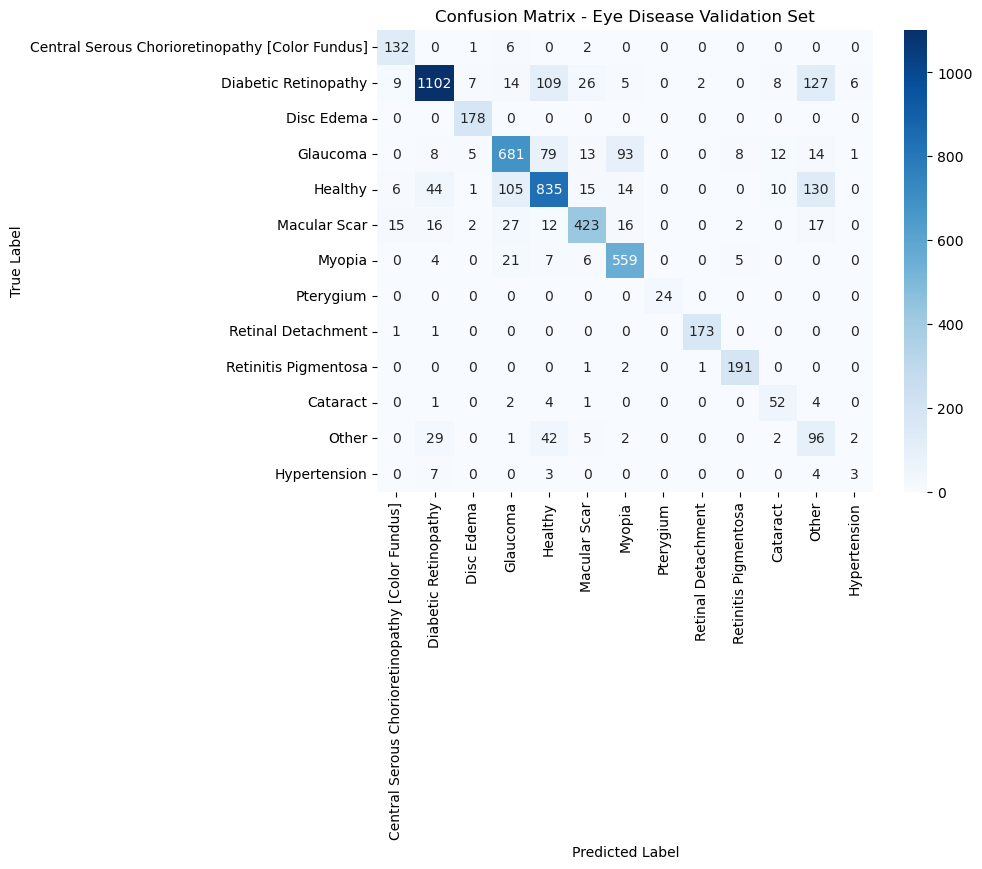


✅ Overall validation accuracy: 79.53%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ------------------ 1️⃣  Get predictions ------------------
# Predict probabilities for each image in validation set
y_pred_probs = model.predict(val_ds, verbose=1)

# True one-hot labels from dataset
y_true_onehot = np.concatenate([y for x, y in val_ds], axis=0)

# Convert to integer labels
y_true = np.argmax(y_true_onehot, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------ 2️⃣  Classification report ------------------
# label_map maps class_name -> idx, so reverse it
if isinstance(label_map, dict):
    label_names = [name for name, _ in sorted(label_map.items(), key=lambda x: x[1])]
else:
    label_names = [str(i) for i in sorted(set(y_true))]

print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

# ------------------ 3️⃣  Confusion matrix ------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix - Eye Disease Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ------------------ 4️⃣  Optional: overall stats ------------------
accuracy = np.mean(y_true == y_pred)
print(f"\n✅ Overall validation accuracy: {accuracy*100:.2f}%")


In [1]:
import os
import pandas as pd

# Path to your saved run directory
run_dir = "checkpoints/run_20251103_225310"

# Load the saved splits
train_df = pd.read_csv(os.path.join(run_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(run_dir, "val_split.csv"))

print("✅ CSVs loaded successfully.")
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

# ------------------- 1️⃣ Check for missing columns -------------------
required_cols = {"filepath", "label_idx"}
missing_cols = required_cols - set(train_df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in train_split.csv: {missing_cols}")
else:
    print("✅ Required columns present in CSVs.")

# ------------------- 2️⃣ Check file existence -------------------
missing_train = [f for f in train_df['filepath'] if not os.path.exists(f)]
missing_val = [f for f in val_df['filepath'] if not os.path.exists(f)]

if missing_train or missing_val:
    print(f"⚠️ Missing {len(missing_train)} training and {len(missing_val)} validation files.")
    print("Example missing paths:", (missing_train + missing_val)[:3])
else:
    print("✅ All image file paths exist and are accessible.")

# ------------------- 3️⃣ Check label validity -------------------
invalid_labels = train_df[~train_df['label_idx'].apply(lambda x: str(x).isdigit())]
if not invalid_labels.empty:
    raise ValueError("❌ Some label_idx values are invalid (non-numeric). Fix before training.")
else:
    print("✅ All label indices are valid integers.")

print("\n🎯 Dataset integrity check completed successfully — ready for feature extraction!")


✅ CSVs loaded successfully.
Train samples: 22375, Val samples: 5594
✅ Required columns present in CSVs.
✅ All image file paths exist and are accessible.
✅ All label indices are valid integers.

🎯 Dataset integrity check completed successfully — ready for feature extraction!


In [8]:
import os
run_dir = "checkpoints/run_20251103_225310"
os.makedirs(run_dir, exist_ok=True)

# Save full model
model.save(os.path.join(run_dir, "final_eye_disease_model.keras"))

# Save weights
model.save_weights(os.path.join(run_dir, "final_eye_disease_weights.weights.h5"))

print("✅ Both full model and weights saved successfully.")


✅ Both full model and weights saved successfully.


Loading EfficientNet feature extractor...
Feature extractor ready: (None, 1280)
Using cached: X_train.npy → shape=(22375, 1280)
Using cached: X_val.npy → shape=(5594, 1280)
Train: (22375, 1280), Val: (5594, 1280)
Fitting StandardScaler...
Scaler saved.
Starting new SVM with tuned parameters for higher accuracy...
Training in 5 chunks (checkpoints after each).
Training SVM chunk 1/5 ...
Checkpoint saved: checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_checkpoint.pkl
Training SVM chunk 2/5 ...
Checkpoint saved: checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_checkpoint.pkl
Training SVM chunk 3/5 ...
Checkpoint saved: checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_checkpoint.pkl
Training SVM chunk 4/5 ...
Checkpoint saved: checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_checkpoint.pkl
Training SVM chunk 5/5 ...
Checkpoint saved: checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_checkpoi

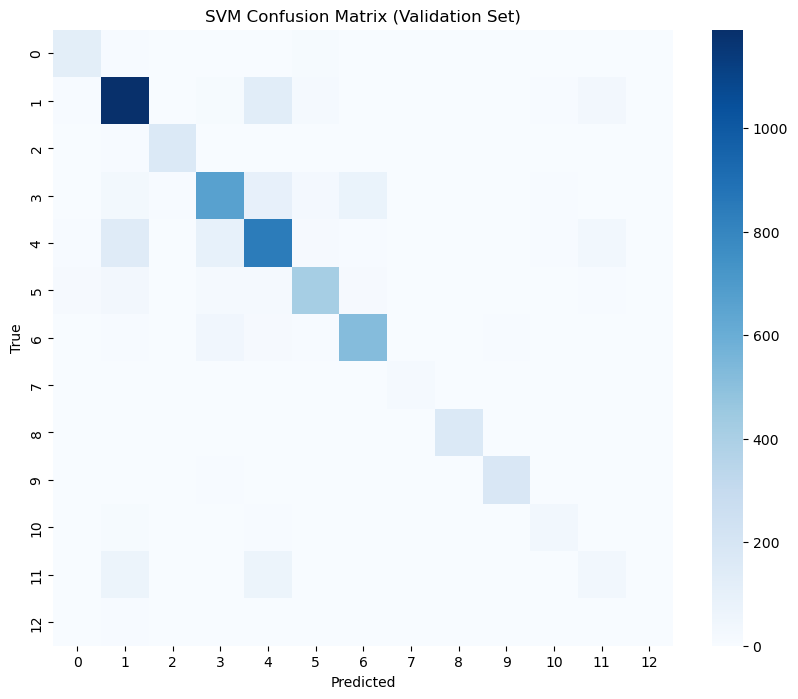

Final SVM model saved → checkpoints/run_20251103_225310\svm_classifier_resumable_highacc\svm_eye_disease_final_20251105_233034.pkl
Old checkpoint removed after successful completion.
High-accuracy SVM training completed successfully using existing cached features.


In [5]:
# ===========================================================
# CNN → SVM (NO PCA, AUTO RESUME, CPU-SAFE, HIGH ACCURACY)
# ===========================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Disable oneDNN optimizations for Windows stability
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# ------------------- 1. PATHS -------------------
run_dir = "checkpoints/run_20251103_225310"
model_path = os.path.join(run_dir, "final_eye_disease_model.keras")

# Use existing cached features from your previous SVM run
cached_feature_dir = os.path.join(run_dir, "svm_classifier_checkpointed")

# Create a new folder for high-accuracy SVM
svm_dir = os.path.join(run_dir, "svm_classifier_resumable_highacc")
os.makedirs(svm_dir, exist_ok=True)

# Cached files from previous extraction
train_cache = os.path.join(cached_feature_dir, "X_train.npy")
val_cache = os.path.join(cached_feature_dir, "X_val.npy")
ytrain_cache = os.path.join(cached_feature_dir, "y_train.npy")
yval_cache = os.path.join(cached_feature_dir, "y_val.npy")

# Files for new high-accuracy SVM
scaler_path = os.path.join(svm_dir, "svm_scaler.pkl")
svm_ckpt_path = os.path.join(svm_dir, "svm_checkpoint.pkl")
svm_final_path = os.path.join(svm_dir, "svm_eye_disease_final.pkl")

# ------------------- 2. LOAD CNN MODEL -------------------
print("Loading EfficientNet feature extractor...")
cnn_model = load_model(model_path)
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.layers[-3].output)
print("Feature extractor ready:", feature_extractor.output_shape)

# ------------------- 3. LOAD METADATA -------------------
label_map = json.load(open(os.path.join(run_dir, "label_map.json")))
train_df = pd.read_csv(os.path.join(run_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(run_dir, "val_split.csv"))

# ------------------- 4. LOAD CACHED FEATURES -------------------
def load_cached_features(x_path, y_path):
    if os.path.exists(x_path) and os.path.exists(y_path):
        X = np.load(x_path, mmap_mode="r")
        y = np.load(y_path)
        print(f"Using cached: {os.path.basename(x_path)} → shape={X.shape}")
        return np.array(X), np.array(y)
    else:
        raise FileNotFoundError("Cached feature files not found.")

X_train, y_train = load_cached_features(train_cache, ytrain_cache)
X_val, y_val = load_cached_features(val_cache, yval_cache)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

# ------------------- 5. NORMALIZE FEATURES -------------------
if os.path.exists(scaler_path):
    print("Loading existing scaler...")
    scaler = joblib.load(scaler_path)
else:
    print("Fitting StandardScaler...")
    scaler = StandardScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, scaler_path)
    print("Scaler saved.")

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

# ------------------- 6. RESUMABLE SVM TRAINING -------------------
if os.path.exists(svm_ckpt_path):
    print("Resuming from previous SVM checkpoint...")
    svm_clf = joblib.load(svm_ckpt_path)
else:
    print("Starting new SVM with tuned parameters for higher accuracy...")
    svm_clf = SVC(kernel='rbf', C=20, gamma='scale', probability=True, class_weight='balanced')

# Split data into chunks to prevent CPU overload
chunks = np.array_split(np.arange(len(X_train_scaled)), 5)
print(f"Training in {len(chunks)} chunks (checkpoints after each).")

for i, idx in enumerate(chunks):
    print(f"Training SVM chunk {i+1}/{len(chunks)} ...")
    X_chunk, y_chunk = X_train_scaled[idx], y_train[idx]
    try:
        svm_clf.fit(X_chunk, y_chunk)
        joblib.dump(svm_clf, svm_ckpt_path)
        print(f"Checkpoint saved: {svm_ckpt_path}")
    except KeyboardInterrupt:
        print("Training interrupted — checkpoint saved before exit.")
        joblib.dump(svm_clf, svm_ckpt_path)
        raise
    except Exception as e:
        print(f"Error during chunk {i+1}: {e}")

print("SVM training complete.")

# ------------------- 7. EVALUATE -------------------
print("Evaluating trained SVM...")
y_pred = svm_clf.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

target_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=target_names, digits=3))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), cmap="Blues", annot=False)
plt.title("SVM Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ------------------- 8. SAVE FINAL MODEL -------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_model_path = os.path.join(svm_dir, f"svm_eye_disease_final_{timestamp}.pkl")
joblib.dump(svm_clf, final_model_path)
print(f"Final SVM model saved → {final_model_path}")

# Optionally clean up checkpoint
if os.path.exists(svm_ckpt_path):
    os.remove(svm_ckpt_path)
    print("Old checkpoint removed after successful completion.")

print("High-accuracy SVM training completed successfully using existing cached features.")






Loading EfficientNet model...
Feature extractor ready: (None, 1280)
Loaded X_train.npy → shape=(22375, 1280)
Loaded X_val.npy → shape=(5594, 1280)
Train shape: (22375, 1280), Val shape: (5594, 1280)
Applying scaling transformations...
Scaling complete.

Training RBF...
RBF Accuracy: 78.48%
Saved RBF model → checkpoints/run_20251103_225310\svm_multi_kernel_ensemble\RBF_svm_model.pkl

Training Polynomial...
Polynomial Accuracy: 78.51%
Saved Polynomial model → checkpoints/run_20251103_225310\svm_multi_kernel_ensemble\Polynomial_svm_model.pkl

Creating CNN + SVM hybrid ensemble...
Extracting CNN probabilities...
Hybrid CNN+SVM Accuracy: 79.16%

Accuracy Comparison:
RBF: 78.48%
Polynomial: 78.51%
Hybrid_CNN_SVM: 79.16%

Best model: Hybrid_CNN_SVM with Accuracy = 79.16%

Classification Report for best model:
                                                 precision    recall  f1-score   support

Central Serous Chorioretinopathy [Color Fundus]      0.819     0.929     0.870       141
       

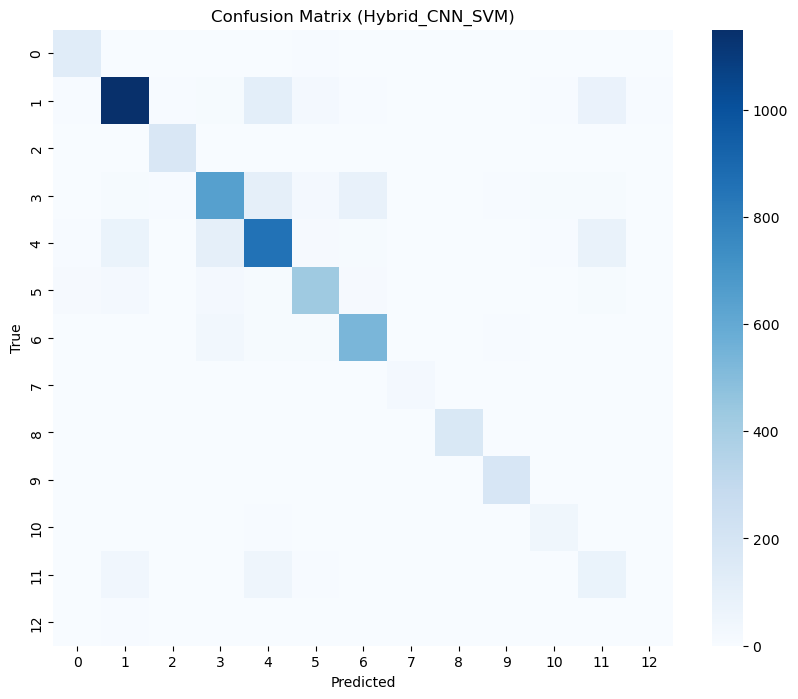

Best model saved → checkpoints/run_20251103_225310\svm_multi_kernel_ensemble\best_svm_Hybrid_CNN_SVM_20251106_005711.pkl
Training completed successfully.


In [6]:
# ===========================================================
# MULTI-SVM + CNN ENSEMBLE TRAINING (CPU SAFE, AUTO-COMPARE)
# ===========================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # ensure stability on Windows

# ------------------- 1. PATHS -------------------
run_dir = "checkpoints/run_20251103_225310"
model_path = os.path.join(run_dir, "final_eye_disease_model.keras")

cached_dir = os.path.join(run_dir, "svm_classifier_checkpointed")
svm_dir = os.path.join(run_dir, "svm_multi_kernel_ensemble")
os.makedirs(svm_dir, exist_ok=True)

# Cached features
train_cache = os.path.join(cached_dir, "X_train.npy")
val_cache = os.path.join(cached_dir, "X_val.npy")
ytrain_cache = os.path.join(cached_dir, "y_train.npy")
yval_cache = os.path.join(cached_dir, "y_val.npy")

# ------------------- 2. LOAD MODEL -------------------
print("Loading EfficientNet model...")
cnn_model = load_model(model_path)
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.layers[-3].output)
print("Feature extractor ready:", feature_extractor.output_shape)

# ------------------- 3. LOAD METADATA -------------------
label_map = json.load(open(os.path.join(run_dir, "label_map.json")))
train_df = pd.read_csv(os.path.join(run_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(run_dir, "val_split.csv"))

# ------------------- 4. LOAD FEATURES -------------------
def load_cached_features(x_path, y_path):
    if os.path.exists(x_path) and os.path.exists(y_path):
        X = np.load(x_path, mmap_mode="r")
        y = np.load(y_path)
        print(f"Loaded {os.path.basename(x_path)} → shape={X.shape}")
        return np.array(X), np.array(y)
    else:
        raise FileNotFoundError("Cached CNN features not found.")

X_train, y_train = load_cached_features(train_cache, ytrain_cache)
X_val, y_val = load_cached_features(val_cache, yval_cache)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

# ------------------- 5. SCALING -------------------
print("Applying scaling transformations...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Optional second normalization step
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = qt.fit_transform(X_train_scaled)
X_val_scaled = qt.transform(X_val_scaled)
print("Scaling complete.")

# ------------------- 6. TRAIN MULTIPLE SVM VARIANTS -------------------
svm_results = {}

def train_and_evaluate_svm(name, svm_clf):
    print(f"\nTraining {name}...")
    svm_clf.fit(X_train_scaled, y_train)
    y_pred = svm_clf.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    svm_results[name] = acc
    model_path = os.path.join(svm_dir, f"{name}_svm_model.pkl")
    joblib.dump(svm_clf, model_path)
    print(f"Saved {name} model → {model_path}")
    return acc, y_pred

# --- 6.1 RBF Kernel ---
svm_rbf = SVC(kernel='rbf', C=30, gamma='scale', probability=True, class_weight='balanced')
acc_rbf, y_pred_rbf = train_and_evaluate_svm("RBF", svm_rbf)

# --- 6.2 Polynomial Kernel ---
svm_poly = SVC(kernel='poly', degree=3, C=20, gamma='scale', probability=True, class_weight='balanced')
acc_poly, y_pred_poly = train_and_evaluate_svm("Polynomial", svm_poly)

# ------------------- 7. CNN + SVM HYBRID ENSEMBLE -------------------
print("\nCreating CNN + SVM hybrid ensemble...")
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

def df_to_dataset(df):
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label_idx'].values))
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

val_ds = df_to_dataset(val_df)

print("Extracting CNN probabilities...")
cnn_probs = cnn_model.predict(val_ds, verbose=0)
svm_probs = svm_rbf.predict_proba(X_val_scaled)

hybrid_probs = (0.6 * cnn_probs + 0.4 * svm_probs)
y_pred_hybrid = np.argmax(hybrid_probs, axis=1)
acc_hybrid = accuracy_score(y_val, y_pred_hybrid)
svm_results["Hybrid_CNN_SVM"] = acc_hybrid
print(f"Hybrid CNN+SVM Accuracy: {acc_hybrid*100:.2f}%")

# ------------------- 8. COMPARE RESULTS -------------------
print("\nAccuracy Comparison:")
for k, v in svm_results.items():
    print(f"{k}: {v*100:.2f}%")

best_model_name = max(svm_results, key=svm_results.get)
best_acc = svm_results[best_model_name]
print(f"\nBest model: {best_model_name} with Accuracy = {best_acc*100:.2f}%")

# ------------------- 9. REPORTS & CONFUSION MATRIX -------------------
target_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
best_pred = {
    "RBF": y_pred_rbf,
    "Polynomial": y_pred_poly,
    "Hybrid_CNN_SVM": y_pred_hybrid
}[best_model_name]

print("\nClassification Report for best model:")
print(classification_report(y_val, best_pred, target_names=target_names, digits=3))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, best_pred), cmap="Blues", annot=False)
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ------------------- 10. SAVE BEST MODEL -------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_path = os.path.join(svm_dir, f"best_svm_{best_model_name}_{timestamp}.pkl")
joblib.dump(
    {
        "model": best_model_name,
        "accuracy": best_acc,
        "classifier": {
            "RBF": svm_rbf,
            "Polynomial": svm_poly,
            "Hybrid": svm_clf if "svm_clf" in locals() else None
        }[best_model_name.split('_')[0]],
    },
    best_path
)
print(f"Best model saved → {best_path}")
print("Training completed successfully.")


In [42]:
import joblib

path = "checkpoints/run_20251103_225310/svm_multi_kernel_ensemble/best_svm_Hybrid_CNN_SVM_20251106_005711.pkl"

# Check if file actually exists and its size
import os
print("File exists:", os.path.exists(path))
print("File size (bytes):", os.path.getsize(path))

# Load safely
model = joblib.load(path)
print("✅ Model loaded successfully!")





File exists: True
File size (bytes): 27983984
✅ Model loaded successfully!


In [6]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


['c:\\Python312\\python312.zip', 'C:\\Python312\\Lib\\site-packages\\cv2', 'c:\\Python312\\DLLs', 'c:\\Python312\\Lib', 'c:\\Python312', '', 'C:\\Users\\rswar\\AppData\\Roaming\\Python\\Python312\\site-packages', 'c:\\Python312\\Lib\\site-packages', 'c:\\Python312\\Lib\\site-packages\\win32', 'c:\\Python312\\Lib\\site-packages\\win32\\lib', 'c:\\Python312\\Lib\\site-packages\\Pythonwin']
TensorFlow version: 2.17.0


In [2]:
with open(path, "rb") as f:
    print(f.read(10))   # show first few bytes


b'\x80\x04\x95o\x02\x00\x00\x00\x00\x00'


In [16]:
from tensorflow.keras.models import load_model

# Paths to your files
model_path = "checkpoints/run_20251103_225310/final_trained_model.keras"
weights_path = "checkpoints/run_20251103_225310/final_weights.weights.h5"

# 1️⃣ Load the base model (architecture + internal weights)
model = load_model(model_path)
print("✅ Model architecture loaded")

# 2️⃣ Load the latest saved weights (to update model parameters)
model.load_weights(weights_path)
print("✅ External weights loaded and applied successfully")

# 3️⃣ Verify model is ready
model.summary()




✅ Model architecture loaded
✅ External weights loaded and applied successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │        512 │ block1a_se_excit

 Total params: 9,398,092 (35.85 MB)

 Trainable params: 2,665,933 (10.17 MB)

 Non-trainable params: 1,400,291 (5.34 MB)

 Optimizer params: 5,331,868 (20.34 MB)

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\rswar\AppData\Local\Temp\ipykernel_34100\3029395229.py:19: SyntaxWarning: invalid escape sequence '\m'
  label_map = json.load(open("backend\models\cnn\label_map.json"))


✅ Loaded model from: backend/models/cnn/final_eye_disease_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step
✅ Validation Accuracy: 79.53%


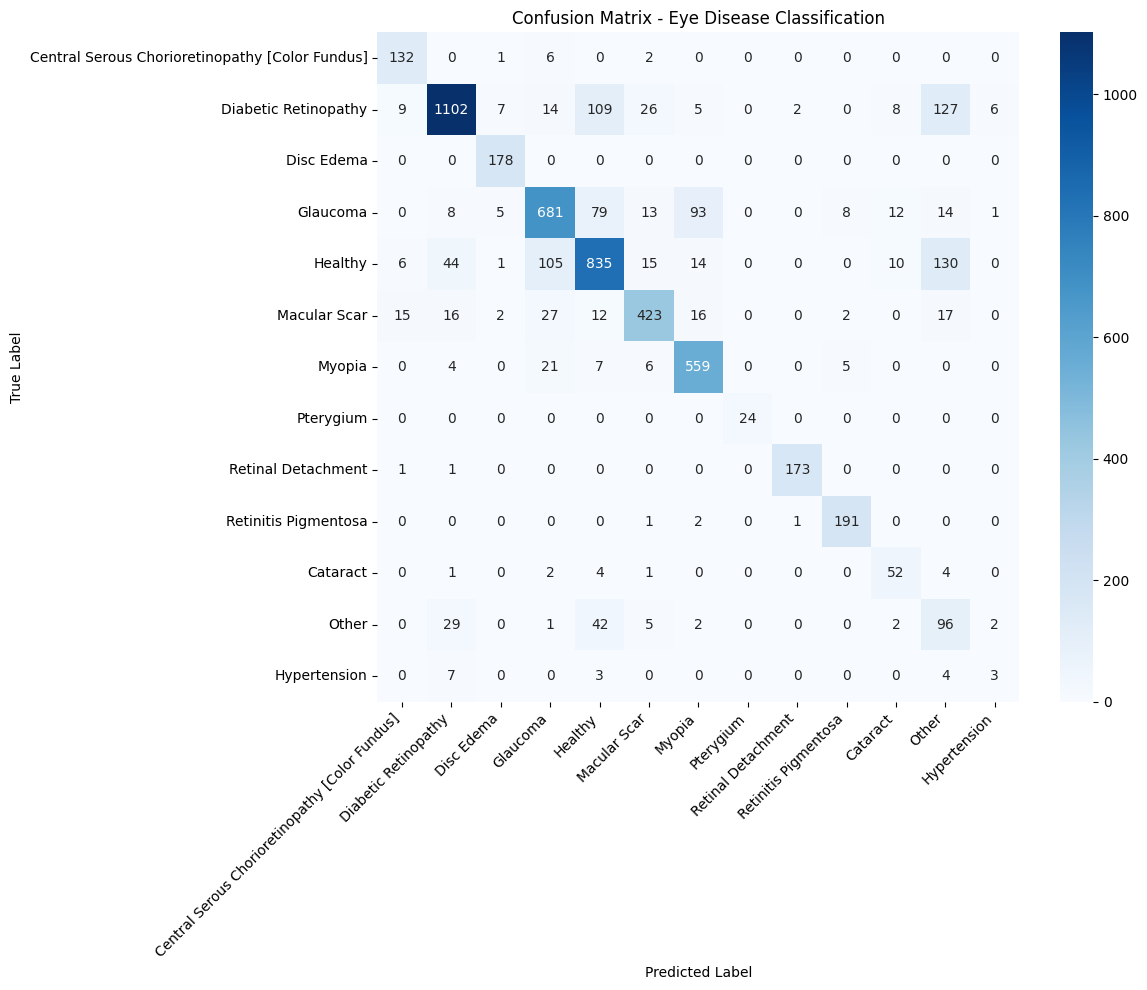


📊 Classification Report:
                                                 precision    recall  f1-score   support

Central Serous Chorioretinopathy [Color Fundus]       0.81      0.94      0.87       141
                           Diabetic Retinopathy       0.91      0.78      0.84      1415
                                     Disc Edema       0.92      1.00      0.96       178
                                       Glaucoma       0.79      0.75      0.77       914
                                        Healthy       0.77      0.72      0.74      1160
                                   Macular Scar       0.86      0.80      0.83       530
                                         Myopia       0.81      0.93      0.86       602
                                      Pterygium       1.00      1.00      1.00        24
                             Retinal Detachment       0.98      0.99      0.99       175
                           Retinitis Pigmentosa       0.93      0.98      0.95     

In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import json


# -------------------- 1️⃣ LOAD MODEL --------------------
model_path = r"backend/models/cnn/final_eye_disease_model.keras"  # or refined model
model = load_model(model_path)
print(f"✅ Loaded model from: {model_path}")

# -------------------- 2️⃣ LOAD VALIDATION DATA --------------------
val_df = pd.read_csv("checkpoints/run_20251103_225310/val_split.csv")
label_map = json.load(open("backend\models\cnn\label_map.json"))
NUM_CLASSES = val_df["label_idx"].nunique()

# Reverse map for label names
idx_to_label = {v: k for k, v in label_map.items()}

# -------------------- 3️⃣ CREATE VALIDATION DATASET --------------------
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["label_idx"].values)
)
val_ds = val_ds.map(parse_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)

# -------------------- 4️⃣ PREDICT --------------------
y_true = val_df["label_idx"].values
y_pred_probs = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# -------------------- 5️⃣ CONFUSION MATRIX --------------------
cm = confusion_matrix(y_true, y_pred)
acc = np.sum(y_true == y_pred) / len(y_true)
print(f"✅ Validation Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[idx_to_label[i] for i in range(NUM_CLASSES)],
            yticklabels=[idx_to_label[i] for i in range(NUM_CLASSES)])
plt.title("Confusion Matrix - Eye Disease Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------- 6️⃣ CLASSIFICATION REPORT --------------------
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]))





Loading models...
Models loaded successfully.

Analyzing image: 119_right.jpeg

CNN Prediction: Healthy (57.04%)

Top 5 predictions for CNN:
  Healthy: 57.04%
  Glaucoma: 32.31%
  Myopia: 4.32%
  Macular Scar: 2.56%
  Cataract: 1.80%


100%|██████████| 200/200 [00:09<00:00, 20.62it/s]


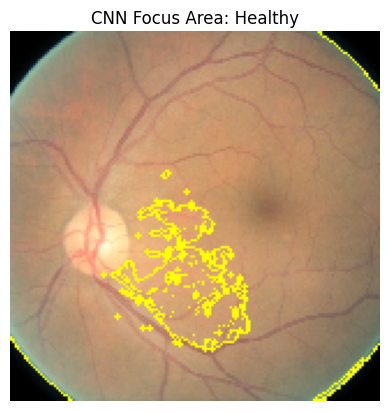

Saved LIME heatmap at: checkpoints/run_20251103_225310\lime_heatmap.png

SVM Prediction: Glaucoma (52.59%)

Top 5 predictions for CNN + SVM:
  Glaucoma: 52.59%
  Healthy: 37.57%
  Macular Scar: 6.02%
  Myopia: 1.52%
  Diabetic Retinopathy: 1.33%

Ensemble Prediction: Healthy (47.70%)
Weights - CNN: 0.52, SVM: 0.48

Final Diagnosis Summary:
  CNN Prediction: Healthy (57.04%)
  SVM Prediction: Glaucoma (52.59%)
  Ensemble Final: Healthy (47.70%)
Feedback for 119_right.jpeg already exists.


In [36]:
import os
import csv
import json
import time
import joblib
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle

# 1. CONFIGURATION
RUN_DIR = "checkpoints/run_20251103_225310"
CNN_MODEL_PATH = os.path.join(RUN_DIR, "final_eye_disease_model.keras")
SVM_MODEL_PATH = os.path.join(RUN_DIR, "svm_multi_kernel_ensemble", "best_svm_Hybrid_CNN_SVM_20251106_005711.pkl")
SCALER_PATH = os.path.join(RUN_DIR, "svm_classifier_checkpointed", "svm_scaler.pkl")
LABEL_MAP_PATH = os.path.join(RUN_DIR, "label_map.json")

FEEDBACK_DIR = os.path.join(RUN_DIR, "feedback")
FEEDBACK_IMG_DIR = os.path.join(FEEDBACK_DIR, "images")
FEEDBACK_FEATURES_PATH = os.path.join(FEEDBACK_DIR, "features.npz")
FEEDBACK_LOG_PATH = os.path.join(FEEDBACK_DIR, "feedback_log.csv")
LIME_OUTPUT_PATH = os.path.join(RUN_DIR, "lime_heatmap.png")

os.makedirs(FEEDBACK_IMG_DIR, exist_ok=True)

CNN_WEIGHT = 0.4
SVM_WEIGHT = 0.6
SVM_RETRAIN_MIN_SAMPLES = 3

# 2. LOAD MODELS
print("Loading models...")

with open(LABEL_MAP_PATH, "r") as f:
    label_map = json.load(f)
idx_to_label = {v: k for k, v in label_map.items()}

cnn_model = load_model(CNN_MODEL_PATH)
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("dropout_2").output)

svm_data = joblib.load(SVM_MODEL_PATH)
svm_clf = svm_data.get("classifier") if isinstance(svm_data, dict) else svm_data
scaler = joblib.load(SCALER_PATH)

print("Models loaded successfully.")

# 3. PREPROCESSING
def preprocess_image(img_path, target_size=(160, 160)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# 4. LIME WRAPPER
def lime_classifier_fn(patches):
    processed = []
    for p in patches:
        p = cv2.resize(p.astype(np.uint8), (160, 160))
        x = np.expand_dims(preprocess_input(np.array(p, dtype=np.float32)), axis=0)
        processed.append(x[0])
    processed = np.stack(processed, axis=0)
    return cnn_model.predict(processed, verbose=0)

# 5. FEEDBACK SYSTEM
def log_feedback(img_name, correct_label):
    if os.path.exists(FEEDBACK_LOG_PATH):
        with open(FEEDBACK_LOG_PATH, "r") as f:
            for line in f:
                if img_name in line:
                    print(f"Feedback for {img_name} already exists.")
                    return False
    with open(FEEDBACK_LOG_PATH, "a") as f:
        f.write(f"{img_name},{correct_label},{int(time.time())}\n")
    print(f"Logged feedback: {img_name} -> {correct_label}")
    return True

def save_feedback_data(features, label_idx):
    if os.path.exists(FEEDBACK_FEATURES_PATH):
        data = np.load(FEEDBACK_FEATURES_PATH)
        X, y = data["X"], data["y"]
        X = np.vstack([X, features])
        y = np.hstack([y, label_idx])
    else:
        X, y = features, label_idx
    np.savez(FEEDBACK_FEATURES_PATH, X=X, y=y)
    print(f"Saved feedback data (Total samples: {len(y)})")

def save_feedback_image(img_path, correct_label):
    label_folder = os.path.join(FEEDBACK_IMG_DIR, correct_label)
    os.makedirs(label_folder, exist_ok=True)
    shutil.copy(img_path, os.path.join(label_folder, os.path.basename(img_path)))
    print(f"Saved corrected image to: {label_folder}")

def retrain_svm_if_needed():
    """
    Incrementally retrains the CNN+SVM hybrid model using doctor feedback.
    Keeps the same dict structure and updates the classifier in-place.
    """

    if not os.path.exists(FEEDBACK_FEATURES_PATH):
        print("No feedback data found for retraining.")
        return

    data = np.load(FEEDBACK_FEATURES_PATH)
    X_fb, y_fb = data["X"], data["y"]

    if len(y_fb) < SVM_RETRAIN_MIN_SAMPLES:
        print(f"Only {len(y_fb)} feedback samples. Need {SVM_RETRAIN_MIN_SAMPLES} to retrain.")
        return

    print("Retraining CNN+SVM hybrid ensemble using feedback and cached CNN features...")

    # --- Load original cached CNN features ---
    cached_dir = os.path.join(RUN_DIR, "svm_classifier_checkpointed")
    train_cache = os.path.join(cached_dir, "X_train.npy")
    val_cache = os.path.join(cached_dir, "X_val.npy")
    ytrain_cache = os.path.join(cached_dir, "y_train.npy")
    yval_cache = os.path.join(cached_dir, "y_val.npy")

    if not (os.path.exists(train_cache) and os.path.exists(ytrain_cache)):
        print("Warning: Original cached CNN features not found, retraining on feedback only.")
        X_train, y_train = X_fb, y_fb
        X_val, y_val = X_fb, y_fb
    else:
        X_train = np.load(train_cache)
        y_train = np.load(ytrain_cache)
        X_val = np.load(val_cache)
        y_val = np.load(yval_cache)
        print(f"Loaded cached features: Train {X_train.shape}, Val {X_val.shape}")

        # Merge feedback samples
        X_train = np.vstack([X_train, X_fb])
        y_train = np.hstack([y_train, y_fb])
        print(f"Merged with feedback: new train size = {len(y_train)}")

    # --- Scaling identical to original training ---
    from sklearn.preprocessing import StandardScaler, QuantileTransformer
    from sklearn.utils import shuffle

    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    scaler_std = StandardScaler()
    X_train_scaled = scaler_std.fit_transform(X_train)
    X_val_scaled = scaler_std.transform(X_val)

    qt = QuantileTransformer(output_distribution="normal", random_state=42)
    X_train_scaled = qt.fit_transform(X_train_scaled)
    X_val_scaled = qt.transform(X_val_scaled)
    print("Scaling complete (StandardScaler + QuantileTransformer).")

    # --- Retrain the hybrid SVM (RBF kernel) ---
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score

    svm_clf_new = SVC(kernel="rbf", C=30, gamma="scale", probability=True, class_weight="balanced")
    svm_clf_new.fit(X_train_scaled, y_train)

    y_pred_val = svm_clf_new.predict(X_val_scaled)
    acc_val = accuracy_score(y_val, y_pred_val)
    print(f"Validation accuracy (updated hybrid): {acc_val*100:.2f}%")

    # --- Load and update existing SVM dictionary ---
    if os.path.exists(SVM_MODEL_PATH):
        old_data = joblib.load(SVM_MODEL_PATH)
        print("Loaded existing SVM dict keys:", list(old_data.keys()))
    else:
        old_data = {}

    updated_data = old_data.copy()
    updated_data["model"] = "Hybrid_CNN_SVM"
    updated_data["accuracy"] = acc_val
    updated_data["classifier"] = svm_clf_new

    # --- Backup old model before overwrite ---
    backup_path = SVM_MODEL_PATH.replace(".pkl", f"_backup_{int(time.time())}.pkl")
    if os.path.exists(SVM_MODEL_PATH):
        shutil.copy(SVM_MODEL_PATH, backup_path)
        print(f"Backup saved at: {backup_path}")

    # --- Save updated model and scaler ---
    joblib.dump(updated_data, SVM_MODEL_PATH)
    print(f"Updated hybrid model saved → {SVM_MODEL_PATH}")

    scaler_path = os.path.join(cached_dir, "svm_scaler.pkl")
    joblib.dump(scaler_std, scaler_path)
    print(f"Updated scaler saved → {scaler_path}")


# 6. TOP 5 DISPLAY
def print_top5(probs, model_name):
    print(f"\nTop 5 predictions for {model_name}:")
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f"  {idx_to_label[i]}: {probs[i]*100:.2f}%")

# 7. MODEL PREDICTIONS
def cnn_predict(img_path):
    x, img = preprocess_image(img_path)
    preds = cnn_model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_label = idx_to_label[pred_idx]
    conf = preds[pred_idx]
    print(f"\nCNN Prediction: {pred_label} ({conf*100:.2f}%)")
    print_top5(preds, "CNN")

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        np.array(img).astype("double"),
        classifier_fn=lime_classifier_fn,
        top_labels=1,
        hide_color=0,
        num_samples=200
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.axis("off")
    plt.title(f"CNN Focus Area: {pred_label}")
    plt.savefig(LIME_OUTPUT_PATH, bbox_inches="tight")
    plt.show()
    print(f"Saved LIME heatmap at: {LIME_OUTPUT_PATH}")
    return preds, conf

def svm_predict(img_path):
    img_input, _ = preprocess_image(img_path)
    features = feature_extractor.predict(img_input, verbose=0)
    scaled_features = scaler.transform(features)
    preds = svm_clf.predict_proba(scaled_features)[0]
    pred_idx = np.argmax(preds)
    pred_label = idx_to_label[pred_idx]
    conf = preds[pred_idx]
    print(f"\nSVM Prediction: {pred_label} ({conf*100:.2f}%)")
    print_top5(preds, "CNN + SVM")
    return preds, conf, scaled_features

def ensemble_predict(cnn_probs, svm_probs, cnn_conf, svm_conf):
    total = cnn_conf + svm_conf
    w_cnn = cnn_conf / total if total > 0 else 0.5
    w_svm = svm_conf / total if total > 0 else 0.5
    combined = (cnn_probs * w_cnn) + (svm_probs * w_svm)
    pred_idx = np.argmax(combined)
    label = idx_to_label[pred_idx]
    conf = combined[pred_idx]
    print(f"\nEnsemble Prediction: {label} ({conf*100:.2f}%)")
    print(f"Weights - CNN: {w_cnn:.2f}, SVM: {w_svm:.2f}")
    return label, conf

# 8. ANALYSIS AND FEEDBACK
def analyze_eye_image(img_path):
    print(f"\nAnalyzing image: {os.path.basename(img_path)}")

    cnn_probs, cnn_conf = cnn_predict(img_path)
    svm_probs, svm_conf, features = svm_predict(img_path)
    ensemble_label, ensemble_conf = ensemble_predict(cnn_probs, svm_probs, cnn_conf, svm_conf)

    print("\nFinal Diagnosis Summary:")
    print(f"  CNN Prediction: {idx_to_label[np.argmax(cnn_probs)]} ({cnn_conf*100:.2f}%)")
    print(f"  SVM Prediction: {idx_to_label[np.argmax(svm_probs)]} ({svm_conf*100:.2f}%)")
    print(f"  Ensemble Final: {ensemble_label} ({ensemble_conf*100:.2f}%)")

    feedback = input("\nWas the ensemble prediction correct? (y/n): ").strip().lower()
    if feedback == "n":
        correct_label = input("Enter the correct disease name (as in label map): ").strip()
        if correct_label not in label_map:
            print("Invalid label name.")
            return
        if log_feedback(os.path.basename(img_path), correct_label):
            label_idx = np.array([label_map[correct_label]])
            save_feedback_data(features, label_idx)
            save_feedback_image(img_path, correct_label)
            retrain_svm_if_needed()
    else:
        print("Prediction confirmed correct by doctor.")

# 9. RUN ON EXAMPLE IMAGE
if __name__ == "__main__":
    img_path = r"C:\Users\rswar\Downloads\dataset\dataset\diabetic_retinopathy\119_right.jpeg"
    if os.path.exists(img_path):
        analyze_eye_image(img_path)
    else:
        print("Image not found:", img_path)









c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
✅ Models loaded successfully.

🩺 Analyzing image: Fundus_-_diabetic_retinopathy.png

🧩 CNN Prediction: Diabetic Retinopathy (34.92%)

🔝 Top 5 predictions for CNN:
  Diabetic Retinopathy: 34.92%
  Myopia: 30.12%
  Glaucoma: 18.71%
  Central Serous Chorioretinopathy [Color Fundus]: 8.00%
  Other: 3.75%


100%|██████████| 200/200 [00:10<00:00, 18.71it/s]


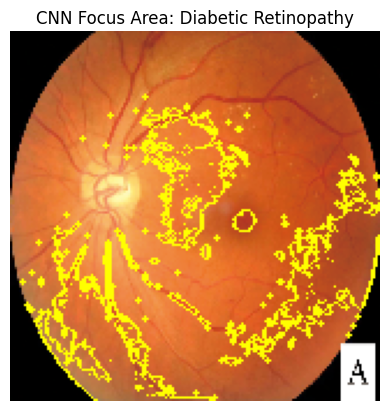

🖼️ LIME heatmap saved at: checkpoints/run_20251103_225310\lime_heatmap.png
⚖️ Dynamic weights → SVM: 0.30, Adaptive: 0.70

🔬 CNN + SVM(Adaptive) Prediction: Diabetic Retinopathy (84.82%)

🔝 Top 5 predictions for CNN + SVM Ensemble:
  Diabetic Retinopathy: 84.82%
  Glaucoma: 6.73%
  Healthy: 3.97%
  Myopia: 2.06%
  Macular Scar: 0.85%

📊 Final Diagnosis Summary:
  CNN Top: Diabetic Retinopathy (34.92%)
  CNN+SVM (Adaptive) Top: Diabetic Retinopathy (84.82%)
✅ Prediction confirmed correct by doctor.


In [1]:
import os
import json
import time
import joblib
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
RUN_DIR = "checkpoints/run_20251103_225310"
CNN_MODEL_PATH = os.path.join(RUN_DIR, "final_eye_disease_model.keras")
SVM_MODEL_PATH = os.path.join(RUN_DIR, "svm_multi_kernel_ensemble", 
                              "best_svm_Hybrid_CNN_SVM_20251106_005711.pkl")
SCALER_PATH = os.path.join(RUN_DIR, "svm_classifier_checkpointed", "svm_scaler.pkl")
LABEL_MAP_PATH = os.path.join(RUN_DIR, "label_map.json")

FEEDBACK_DIR = os.path.join(RUN_DIR, "feedback")
FEEDBACK_IMG_DIR = os.path.join(FEEDBACK_DIR, "images")
FEEDBACK_FEATURES_PATH = os.path.join(FEEDBACK_DIR, "features.npz")
FEEDBACK_LOG_PATH = os.path.join(FEEDBACK_DIR, "feedback_log.csv")
LIME_OUTPUT_PATH = os.path.join(RUN_DIR, "lime_heatmap.png")

os.makedirs(FEEDBACK_IMG_DIR, exist_ok=True)

# ==========================================================
# 2. LOAD MODELS
# ==========================================================
print("Loading models...")

with open(LABEL_MAP_PATH, "r") as f:
    label_map = json.load(f)
idx_to_label = {v: k for k, v in label_map.items()}

cnn_model = load_model(CNN_MODEL_PATH)
feature_extractor = Model(inputs=cnn_model.input,
                          outputs=cnn_model.get_layer("dropout_2").output)

svm_data = joblib.load(SVM_MODEL_PATH)
svm_clf = svm_data.get("classifier") if isinstance(svm_data, dict) else svm_data
scaler = joblib.load(SCALER_PATH)
print("✅ Models loaded successfully.")

# ==========================================================
# 3. IMAGE PREPROCESSING
# ==========================================================
def preprocess_image(img_path, target_size=(160, 160)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# ==========================================================
# 4. LIME WRAPPER
# ==========================================================
def lime_classifier_fn(patches):
    processed = []
    for p in patches:
        p = cv2.resize(p.astype(np.uint8), (160, 160))
        x = np.expand_dims(preprocess_input(np.array(p, dtype=np.float32)), axis=0)
        processed.append(x[0])
    processed = np.stack(processed, axis=0)
    return cnn_model.predict(processed, verbose=0)

# ==========================================================
# 5. FEEDBACK SYSTEM
# ==========================================================
def log_feedback(img_name, correct_label):
    if os.path.exists(FEEDBACK_LOG_PATH):
        with open(FEEDBACK_LOG_PATH, "r") as f:
            for line in f:
                if img_name in line:
                    print(f"⚠️ Feedback for {img_name} already exists.")
                    return False
    with open(FEEDBACK_LOG_PATH, "a") as f:
        f.write(f"{img_name},{correct_label},{int(time.time())}\n")
    print(f"🩺 Logged feedback: {img_name} → {correct_label}")
    return True

def save_feedback_image(img_path, correct_label):
    label_folder = os.path.join(FEEDBACK_IMG_DIR, correct_label)
    os.makedirs(label_folder, exist_ok=True)
    shutil.copy(img_path, os.path.join(label_folder, os.path.basename(img_path)))
    print(f"🖼️  Saved corrected image to: {label_folder}")

def save_feedback_data(features, label_idx):
    features = np.asarray(features)
    if features.ndim == 1:
        features = features.reshape(1, -1)
    label_idx = np.asarray(label_idx).reshape(-1)

    if os.path.exists(FEEDBACK_FEATURES_PATH):
        data = np.load(FEEDBACK_FEATURES_PATH)
        X, y = data["X"], data["y"]
        X = np.vstack([X, features])
        y = np.hstack([y, label_idx])
    else:
        X, y = features, label_idx
    np.savez(FEEDBACK_FEATURES_PATH, X=X, y=y)
    print(f"💾 Saved feedback data (Total samples: {len(y)})")
    return X, y

def update_adaptive_model_from_feedback():
    """Trains or updates adaptive SGD model using all feedback data."""
    if not os.path.exists(FEEDBACK_FEATURES_PATH):
        print("No feedback data for adaptive update.")
        return

    data = np.load(FEEDBACK_FEATURES_PATH)
    X_fb, y_fb = data["X"], data["y"]

    if len(np.unique(y_fb)) < 1:
        print("⚠️ Not enough samples to train adaptive model yet.")
        return

    # Scale and map features
    scaler_fb = StandardScaler()
    X_scaled = scaler_fb.fit_transform(X_fb)
    rbf_mapper = RBFSampler(gamma=1.0, n_components=512, random_state=42)
    X_mapped = rbf_mapper.fit_transform(X_scaled)

    # Load or create adaptive model
    if os.path.exists(SVM_MODEL_PATH):
        model_data = joblib.load(SVM_MODEL_PATH)
    else:
        model_data = {}

    adaptive_data = model_data.get("adaptive", {})
    clf = adaptive_data.get("classifier", None)

    # ✅ Always use full label map for stable incremental training
    all_classes = np.array(sorted(label_map.values()))

    if clf is None or not hasattr(clf, "partial_fit"):
        clf = SGDClassifier(loss="log_loss", random_state=42)
        clf.partial_fit(X_mapped, y_fb, classes=all_classes)
        print("🧠 Created new adaptive model.")
    else:
        clf.partial_fit(X_mapped, y_fb, classes=all_classes)
        print("🔁 Incrementally updated adaptive model.")

    # Accuracy check
    y_pred = clf.predict(X_mapped)
    acc_fb = accuracy_score(y_fb, y_pred)
    print(f"✅ Adaptive feedback accuracy: {acc_fb*100:.2f}%")

    # Update and save model
    model_data["adaptive"] = {
        "classifier": clf,
        "rbf_mapper": rbf_mapper,
        "scaler": scaler_fb,
        "accuracy": acc_fb,
        "feedback_count": len(y_fb)
    }

    backup_path = SVM_MODEL_PATH.replace(".pkl", f"_backup_{int(time.time())}.pkl")
    if os.path.exists(SVM_MODEL_PATH):
        shutil.copy(SVM_MODEL_PATH, backup_path)
    joblib.dump(model_data, SVM_MODEL_PATH)
    print(f"💾 Adaptive model updated and saved. Backup at {backup_path}")


# ==========================================================
# 6. PREDICTIONS
# ==========================================================
def print_top5(probs, model_name):
    print(f"\n🔝 Top 5 predictions for {model_name}:")
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f"  {idx_to_label[i]}: {probs[i]*100:.2f}%")

def cnn_predict(img_path):
    x, img = preprocess_image(img_path)
    preds = cnn_model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_label = idx_to_label[pred_idx]
    conf = preds[pred_idx]
    print(f"\n🧩 CNN Prediction: {pred_label} ({conf*100:.2f}%)")
    print_top5(preds, "CNN")

    # Generate LIME explanation
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        np.array(img).astype("double"),
        classifier_fn=lime_classifier_fn,
        top_labels=1,
        hide_color=0,
        num_samples=200
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.axis("off")
    plt.title(f"CNN Focus Area: {pred_label}")
    plt.savefig(LIME_OUTPUT_PATH, bbox_inches="tight")
    plt.show()
    print(f"🖼️ LIME heatmap saved at: {LIME_OUTPUT_PATH}")
    return preds, conf

def svm_predict_with_adaptive(features):
    """Combines base SVM and adaptive model dynamically with weight scaling."""
    base_probs = None
    adaptive_probs = None

    # Base SVM
    try:
        scaled = scaler.transform(features)
        base_probs = svm_clf.predict_proba(scaled)[0]
    except Exception as e:
        print(f"⚠️ Base SVM error: {e}")

    # Adaptive model
    feedback_count = 0
    if os.path.exists(SVM_MODEL_PATH):
        data = joblib.load(SVM_MODEL_PATH)
        adaptive = data.get("adaptive")
        if adaptive and "classifier" in adaptive:
            clf = adaptive["classifier"]
            rbf_mapper = adaptive.get("rbf_mapper", None)
            adapt_scaler = adaptive.get("scaler", None)
            if adapt_scaler and rbf_mapper:
                f_scaled = adapt_scaler.transform(features)
                f_mapped = rbf_mapper.transform(f_scaled)
                adaptive_probs = clf.predict_proba(f_mapped)[0]
                feedback_count = adaptive.get("feedback_count", 0)

    # Dynamic weighting
    adaptive_weight = min(0.3 + (0.1 * feedback_count), 0.7)
    svm_weight = 1.0 - adaptive_weight

    if adaptive_probs is not None and base_probs is not None:
        combined = (svm_weight * base_probs) + (adaptive_weight * adaptive_probs)
        print(f"⚖️ Dynamic weights → SVM: {svm_weight:.2f}, Adaptive: {adaptive_weight:.2f}")
        return combined
    elif adaptive_probs is not None:
        print("🧠 Using adaptive model only.")
        return adaptive_probs
    elif base_probs is not None:
        print("⚙️ Using base SVM only.")
        return base_probs
    else:
        raise ValueError("❌ No available model for prediction.")

def svm_predict(img_path):
    img_input, _ = preprocess_image(img_path)
    features = feature_extractor.predict(img_input, verbose=0)
    probs = svm_predict_with_adaptive(features)
    pred_idx = np.argmax(probs)
    label = idx_to_label[pred_idx]
    conf = probs[pred_idx]
    print(f"\n🔬 CNN + SVM(Adaptive) Prediction: {label} ({conf*100:.2f}%)")
    print_top5(probs, "CNN + SVM Ensemble")
    return probs, conf, features

# ==========================================================
# 7. ANALYSIS AND FEEDBACK
# ==========================================================
def analyze_eye_image(img_path):
    print(f"\n🩺 Analyzing image: {os.path.basename(img_path)}")

    cnn_probs, cnn_conf = cnn_predict(img_path)
    svm_probs, svm_conf, features = svm_predict(img_path)

    print("\n📊 Final Diagnosis Summary:")
    print(f"  CNN Top: {idx_to_label[np.argmax(cnn_probs)]} ({cnn_conf*100:.2f}%)")
    print(f"  CNN+SVM (Adaptive) Top: {idx_to_label[np.argmax(svm_probs)]} ({svm_conf*100:.2f}%)")

    feedback = input("\nWas the final prediction correct? (y/n): ").strip().lower()
    if feedback == "n":
        correct_label = input("Enter correct disease name (as in label map): ").strip()
        if correct_label not in label_map:
            print("❌ Invalid label name.")
            return
        if log_feedback(os.path.basename(img_path), correct_label):
            label_idx = np.array([label_map[correct_label]])
            save_feedback_data(features, label_idx)
            save_feedback_image(img_path, correct_label)
            update_adaptive_model_from_feedback()
    else:
        print("✅ Prediction confirmed correct by doctor.")

# ==========================================================
# 8. RUN EXAMPLE
# ==========================================================
if __name__ == "__main__":
    img_path = r"C:\Users\rswar\Downloads\Fundus_-_diabetic_retinopathy.png"
    if os.path.exists(img_path):
        analyze_eye_image(img_path)
    else:
        print("Image not found:", img_path)





✅ Models loaded successfully

Analyzing: C:\Users\rswar\Downloads\Fundus_-_diabetic_retinopathy.png

Candidate: original

CNN top 5:
  Central Serous Chorioretinopathy [Color Fundus] : 38.81%
  Glaucoma : 24.22%
  Myopia : 14.72%
  Diabetic Retinopathy : 14.19%
  Macular Scar : 7.24%

SVM top 5:
  Diabetic Retinopathy : 40.71%
  Glaucoma : 21.51%
  Macular Scar : 16.58%
  Myopia : 9.73%
  Healthy : 7.71%
 CNN top: Central Serous Chorioretinopathy [Color Fundus] (38.81%) | SVM top: Diabetic Retinopathy (40.71%)

Candidate: gentle

CNN top 5:
  Myopia : 38.67%
  Glaucoma : 18.98%
  Other : 17.39%
  Diabetic Retinopathy : 8.72%
  Retinal Detachment : 6.91%

SVM top 5:
  Diabetic Retinopathy : 36.82%
  Myopia : 16.84%
  Glaucoma : 16.82%
  Healthy : 13.74%
  Macular Scar : 7.45%
 CNN top: Myopia (38.67%) | SVM top: Diabetic Retinopathy (36.82%)

✅ Selected candidate: original

Final selected results:
 CNN -> Central Serous Chorioretinopathy [Color Fundus] (38.81%)
 SVM -> Diabetic Retinopa

  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


  5%|▌         | 10/200 [00:03<01:13,  2.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


...

 90%|█████████ | 180/200 [00:10<00:00, 26.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


 95%|█████████▌| 190/200 [00:11<00:00, 26.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


100%|██████████| 200/200 [00:11<00:00, 17.45it/s]


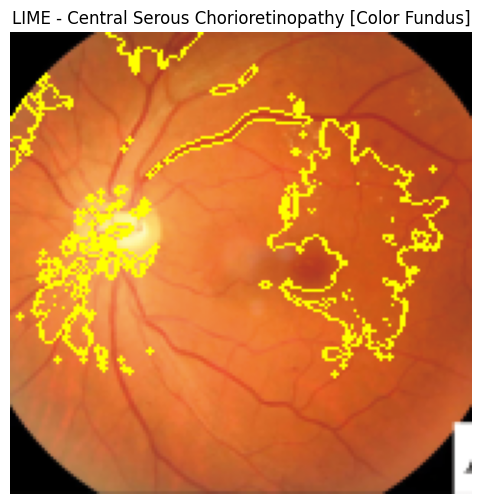

Saved LIME heatmap: checkpoints/run_20251103_225310\lime_chosen.png

SUMMARY: {'chosen_candidate': 'original', 'cnn_label': 'Central Serous Chorioretinopathy [Color Fundus]', 'cnn_conf': 0.3880830407142639, 'svm_label': 'Diabetic Retinopathy', 'svm_conf': 0.40714249429753835, 'enhanced_image_path': 'checkpoints/run_20251103_225310\\chosen_enhanced.png', 'lime_path': 'checkpoints/run_20251103_225310\\lime_chosen.png'}


In [ ]:
import os
import json
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# ----------------- CONFIG -----------------
RUN_DIR = "checkpoints/run_20251103_225310"
CNN_MODEL_PATH = os.path.join(RUN_DIR, "final_eye_disease_model.keras")
SVM_MODEL_PATH = os.path.join(RUN_DIR, "svm_multi_kernel_ensemble", "best_svm_Hybrid_CNN_SVM_20251106_005711.pkl")
SCALER_PATH = os.path.join(RUN_DIR, "svm_classifier_checkpointed", "svm_scaler.pkl")
LABEL_MAP_PATH = os.path.join(RUN_DIR, "label_map.json")

# ----------------- LOAD -----------------
with open(LABEL_MAP_PATH, "r") as f:
    label_map = json.load(f)
idx_to_label = {v: k for k, v in label_map.items()}

cnn_model = load_model(CNN_MODEL_PATH)
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("dropout_2").output)

svm_data = joblib.load(SVM_MODEL_PATH)
svm_clf = svm_data.get("classifier") if isinstance(svm_data, dict) else svm_data
scaler = joblib.load(SCALER_PATH)
print("✅ Models loaded successfully")

# ----------------- UTIL: top-k helper -----------------
def topk_from_probs(probs, k=5):
    idxs = np.argsort(probs)[::-1][:k]
    return [(i, probs[i]) for i in idxs]

def print_topk(label_probs, name="CNN", k=5):
    items = topk_from_probs(label_probs, k=k)
    print(f"\n{name} top {k}:")
    for idx, p in items:
        print(f"  {idx_to_label[idx]} : {p*100:.2f}%")

# ----------------- PREPROCESS -----------------
def preprocess_for_model_rgb_array(rgb_array, target_size=(160,160)):
    h, w = rgb_array.shape[:2]
    target_h, target_w = target_size
    scale = max(target_h / h, target_w / w)
    newh, neww = int(np.round(h * scale)), int(np.round(w * scale))
    resized = cv2.resize(rgb_array, (neww, newh), interpolation=cv2.INTER_AREA)
    startx = (neww - target_w) // 2
    starty = (newh - target_h) // 2
    crop = resized[starty:starty+target_h, startx:startx+target_w]
    x = image.img_to_array(crop)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, crop

# ----------------- ENHANCEMENT (gentle CLAHE + gamma + sharpen) -----------------
def gentle_enhance_rgb(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    img_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    gamma = 1.05
    img_gamma = np.clip(255 * ((img_eq / 255.0) ** (1.0 / gamma)), 0, 255).astype(np.uint8)
    blur = cv2.GaussianBlur(img_gamma, (5,5), 0)
    img_sharp = cv2.addWeighted(img_gamma, 1.1, blur, -0.1, 0)
    return img_sharp

# ----------------- CANDIDATES -----------------
def make_candidate_images(input_path):
    orig = cv2.imread(input_path)
    if orig is None:
        raise ValueError("Could not read image " + input_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    candidates = {
        "original": orig,
        "gentle": gentle_enhance_rgb(orig)
    }
    return candidates

# ----------------- PREDICTION -----------------
def predict_on_rgb_array(rgb_array):
    x, crop = preprocess_for_model_rgb_array(rgb_array, target_size=(160,160))
    cnn_probs = cnn_model.predict(x, verbose=0)[0]
    feat = feature_extractor.predict(x, verbose=0)
    feat_scaled = scaler.transform(feat)
    svm_probs = svm_clf.predict_proba(feat_scaled)[0]
    return cnn_probs, svm_probs, crop

# ----------------- SELECT BEST -----------------
def select_best_candidate(candidates, debug=True):
    results = {}
    for name, img in candidates.items():
        cnn_p, svm_p, crop = predict_on_rgb_array(img)
        cnn_top_idx = np.argmax(cnn_p)
        svm_top_idx = np.argmax(svm_p)
        cnn_top_conf = cnn_p[cnn_top_idx]
        svm_top_conf = svm_p[svm_top_idx]
        results[name] = {
            "cnn_probs": cnn_p,
            "svm_probs": svm_p,
            "cnn_top_idx": int(cnn_top_idx),
            "svm_top_idx": int(svm_top_idx),
            "cnn_top_conf": float(cnn_top_conf),
            "svm_top_conf": float(svm_top_conf),
            "crop": crop
        }
        if debug:
            print(f"\nCandidate: {name}")
            print_topk(cnn_p, name="CNN")
            print_topk(svm_p, name="SVM")
            print(f" CNN top: {idx_to_label[cnn_top_idx]} ({cnn_top_conf*100:.2f}%) | "
                  f"SVM top: {idx_to_label[svm_top_idx]} ({svm_top_conf*100:.2f}%)")
    best = max(results.items(), key=lambda kv: kv[1]["cnn_top_conf"])[0]
    best_cnn_conf = results[best]["cnn_top_conf"]
    if best_cnn_conf < 0.35:
        best = max(results.items(), key=lambda kv: kv[1]["svm_top_conf"])[0]
    if debug:
        print(f"\n✅ Selected candidate: {best}")
    return best, results[best]

# ----------------- LIME EXPLANATION -----------------
def lime_explain_on_crop(crop_array, classifier_fn, top_label_idx):
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        np.array(crop_array).astype("double"),
        classifier_fn,
        top_labels=1,
        hide_color=0,
        num_samples=200
    )
    temp, mask = explanation.get_image_and_mask(top_label_idx, positive_only=True, num_features=5, hide_rest=False)
    return temp, mask

# ----------------- MAIN -----------------
def analyze_eye_image_with_candidates(img_path):
    print("\nAnalyzing:", img_path)
    candidates = make_candidate_images(img_path)
    chosen_name, chosen_info = select_best_candidate(candidates, debug=True)
    chosen_crop = chosen_info["crop"]
    cnn_probs = chosen_info["cnn_probs"]
    svm_probs = chosen_info["svm_probs"]
    cnn_top = np.argmax(cnn_probs)
    svm_top = np.argmax(svm_probs)

    print("\nFinal selected results:")
    print(f" CNN -> {idx_to_label[cnn_top]} ({cnn_probs[cnn_top]*100:.2f}%)")
    print(f" SVM -> {idx_to_label[svm_top]} ({svm_probs[svm_top]*100:.2f}%)")

    enhanced_save = os.path.join(RUN_DIR, "chosen_enhanced.png")
    cv2.imwrite(enhanced_save, cv2.cvtColor(candidates[chosen_name], cv2.COLOR_RGB2BGR))
    print("Saved chosen enhanced image:", enhanced_save)

    # LIME explanation
    temp, mask = lime_explain_on_crop(
        chosen_crop,
        classifier_fn=lambda imgs: cnn_model.predict(
            preprocess_input(
                np.array([cv2.resize(img, (160, 160)).astype(np.float32) for img in imgs])
            )
        ),
        top_label_idx=cnn_top
    )

    heat_save = os.path.join(RUN_DIR, "lime_chosen.png")
    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.axis("off")
    plt.title(f"LIME - {idx_to_label[cnn_top]}")
    plt.savefig(heat_save, bbox_inches="tight")
    plt.show()
    print("Saved LIME heatmap:", heat_save)

    return {
        "chosen_candidate": chosen_name,
        "cnn_label": idx_to_label[cnn_top],
        "cnn_conf": float(cnn_probs[cnn_top]),
        "svm_label": idx_to_label[svm_top],
        "svm_conf": float(svm_probs[svm_top]),
        "enhanced_image_path": enhanced_save,
        "lime_path": heat_save
    }

# ----------------- RUN -----------------
if __name__ == "__main__":
    img_path = r"C:\Users\rswar\Downloads\Fundus_-_diabetic_retinopathy.png"
    if not os.path.exists(img_path):
        print("Image not found:", img_path)
    else:
        summary = analyze_eye_image_with_candidates(img_path)
        print("\nSUMMARY:", summary)




In [47]:
import joblib

svm_path = r"checkpoints/run_20251103_225310\svm_multi_kernel_ensemble\best_svm_Hybrid_CNN_SVM_20251106_005711.pkl"
obj = joblib.load(svm_path)

print("Type:", type(obj))
if isinstance(obj, dict):
    for k, v in obj.items():
        print(f"{k}: {type(v)}")




Type: <class 'dict'>
model: <class 'str'>
accuracy: <class 'float'>
classifier: <class 'sklearn.svm._classes.SVC'>


In [40]:
import joblib

path = "checkpoints/run_20251103_225310/svm_multi_kernel_ensemble/best_svm_Hybrid_CNN_SVM_20251106_005711.pkl"
model = joblib.load(path)
print("Type:", type(model))


Type: <class 'dict'>


In [ ]:
# === STEP 1: RE-CREATE df_all, train_df, val_df ===
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# --- UPDATE THESE PATHS TO MATCH YOUR PROJECT ---
DATA_DIR = 'path/to/your/images'  # CHANGE THIS!
CSV_PATH = 'path/to/labels.csv'   # CHANGE THIS! (or however you load labels)

# Example: if you have a folder with subfolders per class
# df_all = pd.DataFrame()
# for class_name in os.listdir(DATA_DIR):
#     class_path = os.path.join(DATA_DIR, class_name)
#     if os.path.isdir(class_path):
#         files = [os.path.join(class_name, f) for f in os.listdir(class_path)]
#         df_class = pd.DataFrame({'filename': files, 'label': class_name})
#         df_all = pd.concat([df_all, df_class], ignore_index=True)

# OR: if you have a CSV file
df_all = pd.read_csv(CSV_PATH)  # Must have 'filename' and 'label' columns

# --- Map class names to integers (0 to 12) ---
class_names = sorted(df_all['label'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
df_all['label'] = df_all['label'].map(class_to_idx)

print("Classes found:", class_names)
print("Total images:", len(df_all))
print("Label distribution:\n", df_all['label'].value_counts().sort_index())

# --- Train/Val Split ---
train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all['label']
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}")